In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

# ============================================================
# MAIN CONFIG
# ============================================================
DATASET_NAME = "old"
LABEL_NAME = "box2deg"

CASE_DIR = Path(r"C:\Users\_s2218026\Documents\lab\mcs_output\exactlead_box2deg_case_tables_old_2009_2025_UPDATED")


OUT_DIR  = Path(r"C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_UPDATED")
OUT_DIR.mkdir(parents=True, exist_ok=True)

LEADS = [6, 12, 24, 48]
RANDOM_STATE = 42
N_SPLITS = 5

FEATURE_COLS = [
    "lon", "lat", "month",
    "area_km2", "tb_mean", "tb_min",
    "speed_kmh", "direction_deg",
    "eta850_abs", "rh600", "wshear_200_850",
    "pi_vmax_ms", "gpi"
]

ID_COLS = [
    "track_id", "time", "centroid_lon", "centroid_lat"
]

print("CASE_DIR:", CASE_DIR)
print("OUT_DIR:", OUT_DIR)

CASE_DIR: C:\Users\_s2218026\Documents\lab\mcs_output\exactlead_box2deg_case_tables_old_2009_2025_UPDATED
OUT_DIR: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_UPDATED


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd

# ============================================================
# MAIN CONFIG
# ============================================================
DATASET_NAME = "old"
LABEL_NAME = "box2deg"

CASE_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\exactlead_box2deg_case_tables_old_2009_2025_JJASO"
)

OUT_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

LEADS = [6, 12, 24, 48]
RANDOM_STATE = 42
N_SPLITS = 5

FEATURE_COLS = [
    "lon", "lat", "month",
    "area_km2", "tb_mean", "tb_min",
    "speed_kmh", "direction_deg",
    "eta850_abs", "rh600", "wshear_200_850",
    "pi_vmax_ms", "gpi"
]

ID_COLS = [
    "track_id", "time", "centroid_lon", "centroid_lat"
]

print("CASE_DIR:", CASE_DIR)
print("OUT_DIR:", OUT_DIR)

CASE_DIR: C:\Users\_s2218026\Documents\lab\mcs_output\exactlead_box2deg_case_tables_old_2009_2025_JJASO
OUT_DIR: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final


In [4]:
# ============================================================
# CASE TABLE QC
# ============================================================
qc_rows = []

for L in LEADS:
    fp = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

    if not fp.exists():
        print("[MISSING]", fp)
        continue

    df = pd.read_csv(fp)
    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)

    qc_rows.append({
        "lead_h": L,
        "rows": len(df),
        "positive": int(df["y"].sum()),
        "negative": int((df["y"] == 0).sum()),
        "pos_frac": float(df["y"].mean()),
        "time_min": df["time"].min(),
        "time_max": df["time"].max(),
        "unique_tracks": df["track_id"].nunique(),
        "any_predictor_nan_frac": float(df[FEATURE_COLS].isna().any(axis=1).mean()),
        "speed_nan_frac": float(df["speed_kmh"].isna().mean()),
        "direction_nan_frac": float(df["direction_deg"].isna().mean()),
        "pi_nan_frac": float(df["pi_vmax_ms"].isna().mean()),
        "gpi_nan_frac": float(df["gpi"].isna().mean()),
    })

qc = pd.DataFrame(qc_rows)
qc.to_csv(OUT_DIR / "case_table_qc.csv", index=False)

qc

,lead_h,rows,positive,negative,pos_frac,time_min,time_max,unique_tracks,any_predictor_nan_frac,speed_nan_frac,direction_nan_frac,pi_nan_frac,gpi_nan_frac
0,6,1338,223,1115,0.166667,2009-06-01 09:00:00,2025-10-28 00:00:00,1338,0.577728,0.464873,0.464873,0.195815,0.195815
1,12,1242,207,1035,0.166667,2009-06-01 00:00:00,2025-10-29 21:00:00,1240,0.549114,0.452496,0.452496,0.179549,0.179549
2,24,1050,175,875,0.166667,2009-06-03 09:00:00,2025-10-30 06:00:00,1049,0.602857,0.498095,0.498095,0.191429,0.191429
3,48,756,126,630,0.166667,2009-06-02 09:00:00,2025-10-28 18:00:00,756,0.630952,0.500000,0.500000,0.214286,0.214286


In [5]:
# ============================================================
# MODELS + HELPERS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier


def get_models(random_state=42):
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            solver="lbfgs"
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=600,
            random_state=random_state,
            class_weight="balanced",
            n_jobs=-1
        ),

        "AdaBoost": AdaBoostClassifier(
            n_estimators=600,
            random_state=random_state
        ),

        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            alpha=1e-4,
            learning_rate_init=0.001,
            max_iter=1000,
            random_state=random_state
        ),

        "KNN": KNeighborsClassifier(
            n_neighbors=5
        ),

        "Naive Bayes": GaussianNB(),

        "SVM": SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=random_state
        ),

        "QDA": QuadraticDiscriminantAnalysis(
            reg_param=0.01
        ),

        "Decision Tree": DecisionTreeClassifier(
            random_state=random_state,
            class_weight="balanced"
        ),
    }


def model_needs_scaling(model_name):
    return model_name in [
        "Logistic Regression",
        "MLP",
        "KNN",
        "Naive Bayes",
        "SVM",
        "QDA"
    ]


def make_pipeline(model_name, model):
    steps = [
        ("imputer", SimpleImputer(strategy="median"))
    ]

    if model_needs_scaling(model_name):
        steps.append(("scaler", StandardScaler()))

    steps.append(("model", model))

    return Pipeline(steps)


def get_cv(y, groups=None, n_splits=5, random_state=42):
    n_pos = int(np.sum(y == 1))
    n_neg = int(np.sum(y == 0))

    n_splits_eff = min(n_splits, n_pos, n_neg)

    if n_splits_eff < 2:
        raise ValueError("Not enough positive/negative samples for CV.")

    if groups is not None:
        return StratifiedGroupKFold(
            n_splits=n_splits_eff,
            shuffle=True,
            random_state=random_state
        ), "StratifiedGroupKFold", n_splits_eff

    return StratifiedKFold(
        n_splits=n_splits_eff,
        shuffle=True,
        random_state=random_state
    ), "StratifiedKFold", n_splits_eff


def safe_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    out = {
        "threshold": float(threshold),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    try:
        out["roc_auc"] = roc_auc_score(y_true, y_score)
    except Exception:
        out["roc_auc"] = np.nan

    try:
        out["pr_auc"] = average_precision_score(y_true, y_score)
    except Exception:
        out["pr_auc"] = np.nan

    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    except Exception:
        tn, fp, fn, tp = np.nan, np.nan, np.nan, np.nan

    out["tn"] = tn
    out["fp"] = fp
    out["fn"] = fn
    out["tp"] = tp

    return out


def threshold_scan(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    valid = np.isfinite(y_score)
    y_true = y_true[valid]
    y_score = y_score[valid]

    if len(y_true) == 0:
        return pd.DataFrame()

    # percentile-based thresholds are more stable than fixed linear spacing
    thresholds = np.unique(np.nanpercentile(y_score, np.linspace(0, 100, 501)))

    rows = []

    for th in thresholds:
        m = safe_metrics(y_true, y_score, threshold=th)
        rows.append(m)

    scan = pd.DataFrame(rows)
    return scan.sort_values(["f1", "recall", "precision"], ascending=False).reset_index(drop=True)

In [6]:
# ============================================================
# MANUAL 5-FOLD GROUPED CV
# Saves:
#   1. fold metrics
#   2. out-of-fold probabilities
#   3. default-threshold global metrics
#   4. tuned-threshold global metrics
# ============================================================

def run_one_model_cv(
    case_df,
    lead_h,
    model_name,
    model,
    dataset_name=DATASET_NAME,
    label_name=LABEL_NAME,
    random_state=RANDOM_STATE,
    n_splits=N_SPLITS
):
    df = case_df.copy()
    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)

    X = df[FEATURE_COLS].copy()
    y = df["y"].astype(int).values
    groups = df["track_id"].astype(str).values if "track_id" in df.columns else None

    cv, cv_name, n_splits_eff = get_cv(
        y=y,
        groups=groups,
        n_splits=n_splits,
        random_state=random_state
    )

    pipe = make_pipeline(model_name, model)

    fold_rows = []
    oof_rows = []

    if groups is not None:
        splitter = cv.split(X, y, groups)
    else:
        splitter = cv.split(X, y)

    for fold_id, (train_idx, test_idx) in enumerate(splitter, start=1):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        pipe.fit(X_train, y_train)

        if hasattr(pipe, "predict_proba"):
            y_score = pipe.predict_proba(X_test)[:, 1]
        else:
            # fallback, not expected for current models
            y_score = pipe.decision_function(X_test)
            y_score = (y_score - np.nanmin(y_score)) / (np.nanmax(y_score) - np.nanmin(y_score) + 1e-12)

        fold_metric = safe_metrics(y_test, y_score, threshold=0.5)

        fold_metric.update({
            "dataset": dataset_name,
            "label": label_name,
            "lead_h": lead_h,
            "model": model_name,
            "fold": fold_id,
            "cv": cv_name,
            "n_splits": n_splits_eff,
            "train_n": len(train_idx),
            "test_n": len(test_idx),
            "train_pos": int(y_train.sum()),
            "test_pos": int(y_test.sum()),
            "train_neg": int((y_train == 0).sum()),
            "test_neg": int((y_test == 0).sum()),
        })

        fold_rows.append(fold_metric)

        oof = df.iloc[test_idx][ID_COLS].copy()
        oof["dataset"] = dataset_name
        oof["label"] = label_name
        oof["lead_h"] = lead_h
        oof["model"] = model_name
        oof["fold"] = fold_id
        oof["y_true"] = y_test
        oof["y_score"] = y_score
        oof["y_pred_default"] = (y_score >= 0.5).astype(int)

        oof_rows.append(oof)

    fold_df = pd.DataFrame(fold_rows)
    oof_df = pd.concat(oof_rows, ignore_index=True)

    # ------------------------------------------------------------
    # Global OOF default-threshold metrics
    # ------------------------------------------------------------
    default_metrics = safe_metrics(
        oof_df["y_true"].values,
        oof_df["y_score"].values,
        threshold=0.5
    )

    default_row = {
        "dataset": dataset_name,
        "label": label_name,
        "lead_h": lead_h,
        "model": model_name,
        "metric_type": "oof_default_0.5",
        **default_metrics
    }

    # ------------------------------------------------------------
    # OOF threshold tuning
    # ------------------------------------------------------------
    scan = threshold_scan(
        oof_df["y_true"].values,
        oof_df["y_score"].values
    )

    if len(scan) > 0:
        best = scan.iloc[0].to_dict()
        best_threshold = float(best["threshold"])
    else:
        best = {}
        best_threshold = 0.5

    oof_df["y_pred_tuned"] = (oof_df["y_score"] >= best_threshold).astype(int)

    tuned_metrics = safe_metrics(
        oof_df["y_true"].values,
        oof_df["y_score"].values,
        threshold=best_threshold
    )

    tuned_row = {
        "dataset": dataset_name,
        "label": label_name,
        "lead_h": lead_h,
        "model": model_name,
        "metric_type": "oof_tuned_threshold",
        **tuned_metrics
    }

    return fold_df, oof_df, pd.DataFrame([default_row, tuned_row]), scan

In [7]:
# ============================================================
# RUN ALL MODELS / ALL LEADS
# ============================================================

models = get_models(random_state=RANDOM_STATE)

all_fold_results = []
all_oof_results = []
all_oof_summary = []
all_threshold_scans = []

for L in LEADS:
    case_csv = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

    if not case_csv.exists():
        print("[MISSING]", case_csv)
        continue

    case_df = pd.read_csv(case_csv)

    print("\n" + "=" * 80)
    print(f"LEAD {L}h | rows={len(case_df)} | positives={int(case_df['y'].sum())} | negatives={int((case_df['y'] == 0).sum())}")
    print("=" * 80)

    for model_name, model in models.items():
        print(f"\nRunning model: {model_name}")

        try:
            fold_df, oof_df, oof_summary_df, scan_df = run_one_model_cv(
                case_df=case_df,
                lead_h=L,
                model_name=model_name,
                model=model,
                dataset_name=DATASET_NAME,
                label_name=LABEL_NAME,
                random_state=RANDOM_STATE,
                n_splits=N_SPLITS
            )

            all_fold_results.append(fold_df)
            all_oof_results.append(oof_df)
            all_oof_summary.append(oof_summary_df)

            scan_df["dataset"] = DATASET_NAME
            scan_df["label"] = LABEL_NAME
            scan_df["lead_h"] = L
            scan_df["model"] = model_name
            all_threshold_scans.append(scan_df)

            # Save model-specific OOF predictions immediately
            safe_model_name = model_name.replace(" ", "_").replace("/", "_")
            oof_fp = OUT_DIR / f"oof_{DATASET_NAME}_{LABEL_NAME}_{L}h_{safe_model_name}.csv"
            oof_df.to_csv(oof_fp, index=False)

            scan_fp = OUT_DIR / f"threshold_scan_{DATASET_NAME}_{LABEL_NAME}_{L}h_{safe_model_name}.csv"
            scan_df.to_csv(scan_fp, index=False)

        except Exception as e:
            print(f"[ERROR] {model_name} lead {L}h failed: {e}")

            err_row = pd.DataFrame([{
                "dataset": DATASET_NAME,
                "label": LABEL_NAME,
                "lead_h": L,
                "model": model_name,
                "error": str(e)
            }])

            all_oof_summary.append(err_row)

# ------------------------------------------------------------
# Save combined outputs
# ------------------------------------------------------------
fold_results = pd.concat(all_fold_results, ignore_index=True)
oof_results = pd.concat(all_oof_results, ignore_index=True)
oof_summary = pd.concat(all_oof_summary, ignore_index=True)
threshold_scans = pd.concat(all_threshold_scans, ignore_index=True)

fold_results.to_csv(OUT_DIR / "fold_results_all_models.csv", index=False)
oof_results.to_csv(OUT_DIR / "oof_predictions_all_models.csv", index=False)
oof_summary.to_csv(OUT_DIR / "oof_summary_default_and_tuned_all_models.csv", index=False)
threshold_scans.to_csv(OUT_DIR / "threshold_scans_all_models.csv", index=False)

print("\n[SAVED]")
print(OUT_DIR / "fold_results_all_models.csv")
print(OUT_DIR / "oof_predictions_all_models.csv")
print(OUT_DIR / "oof_summary_default_and_tuned_all_models.csv")
print(OUT_DIR / "threshold_scans_all_models.csv")


LEAD 6h | rows=1338 | positives=223 | negatives=1115

Running model: Logistic Regression

Running model: Random Forest

Running model: AdaBoost

Running model: MLP

Running model: KNN

Running model: Naive Bayes

Running model: SVM

Running model: QDA

Running model: Decision Tree

LEAD 12h | rows=1242 | positives=207 | negatives=1035

Running model: Logistic Regression

Running model: Random Forest

Running model: AdaBoost

Running model: MLP

Running model: KNN

Running model: Naive Bayes

Running model: SVM

Running model: QDA

Running model: Decision Tree

LEAD 24h | rows=1050 | positives=175 | negatives=875

Running model: Logistic Regression

Running model: Random Forest

Running model: AdaBoost

Running model: MLP

Running model: KNN

Running model: Naive Bayes

Running model: SVM

Running model: QDA

Running model: Decision Tree

LEAD 48h | rows=756 | positives=126 | negatives=630

Running model: Logistic Regression

Running model: Random Forest

Running model: AdaBoost

Runni

In [8]:
# ============================================================
# FOLD-LEVEL MEAN ± STD SUMMARY
# ============================================================

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

summary_rows = []

for (lead_h, model), g in fold_results.groupby(["lead_h", "model"]):
    row = {
        "dataset": DATASET_NAME,
        "label": LABEL_NAME,
        "lead_h": lead_h,
        "model": model,
        "folds": g["fold"].nunique(),
        "samples_mean": g["test_n"].mean(),
        "test_pos_mean": g["test_pos"].mean(),
        "test_neg_mean": g["test_neg"].mean(),
    }

    for metric in metric_cols:
        row[f"{metric}_mean"] = g[metric].mean()
        row[f"{metric}_std"] = g[metric].std()

    summary_rows.append(row)

cv_summary = pd.DataFrame(summary_rows)
cv_summary = cv_summary.sort_values(["lead_h", "f1_mean"], ascending=[True, False])

cv_summary.to_csv(OUT_DIR / "cv_summary_mean_std_all_models.csv", index=False)

cv_summary

,dataset,label,lead_h,model,folds,samples_mean,test_pos_mean,test_neg_mean,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
7,old,box2deg,6,Random Forest,5,267.6,44.6,223.0,0.881939,0.017437,0.709113,0.069058,0.485514,0.060165,0.573616,0.048312,0.913459,0.015077,0.689244,0.082639
4,old,box2deg,6,MLP,5,267.6,44.6,223.0,0.865490,0.019772,0.606092,0.077160,0.537561,0.054127,0.567048,0.047656,0.862735,0.025697,0.589701,0.094882
5,old,box2deg,6,Naive Bayes,5,267.6,44.6,223.0,0.867748,0.029643,0.622934,0.073317,0.521420,0.063010,0.565751,0.056988,0.857036,0.018951,0.558387,0.053605
3,old,box2deg,6,Logistic Regression,5,267.6,44.6,223.0,0.794502,0.027779,0.432452,0.029564,0.787388,0.033684,0.557680,0.026954,0.859078,0.006871,0.563711,0.044630
0,old,box2deg,6,AdaBoost,5,267.6,44.6,223.0,0.871463,0.013470,0.638368,0.082320,0.487916,0.065880,0.552209,0.068927,0.893033,0.026889,0.615704,0.104763
8,old,box2deg,6,SVM,5,267.6,44.6,223.0,0.875971,0.028445,0.691958,0.102746,0.458491,0.079278,0.549054,0.078862,0.889125,0.018141,0.656097,0.070799
6,old,box2deg,6,QDA,5,267.6,44.6,223.0,0.863262,0.022109,0.612363,0.046917,0.459750,0.067482,0.523923,0.058057,0.860817,0.018106,0.554479,0.057484
1,old,box2deg,6,Decision Tree,5,267.6,44.6,223.0,0.838582,0.011640,0.509109,0.090780,0.492446,0.061802,0.498403,0.066212,0.699643,0.028938,0.336848,0.075899
2,old,box2deg,6,KNN,5,267.6,44.6,223.0,0.862502,0.023539,0.643812,0.113367,0.400154,0.039376,0.489909,0.049417,0.800199,0.039680,0.502049,0.066601
14,old,box2deg,12,Naive Bayes,5,248.4,41.4,207.0,0.867128,0.019932,0.624628,0.094757,0.491539,0.088491,0.548814,0.086843,0.843642,0.029028,0.543773,0.064868


In [9]:
# ============================================================
# BEST MODELS BY LEAD
# Based on fold-level mean F1
# ============================================================

best_by_lead_cv = (
    cv_summary
    .sort_values(["lead_h", "f1_mean"], ascending=[True, False])
    .groupby("lead_h")
    .head(1)
    .reset_index(drop=True)
)

best_by_lead_cv.to_csv(OUT_DIR / "best_models_by_lead_cv_f1.csv", index=False)

best_by_lead_cv[
    [
        "lead_h", "model",
        "f1_mean", "precision_mean", "recall_mean",
        "roc_auc_mean", "pr_auc_mean"
    ]
]

,lead_h,model,f1_mean,precision_mean,recall_mean,roc_auc_mean,pr_auc_mean
0,6,Random Forest,0.573616,0.709113,0.485514,0.913459,0.689244
1,12,Naive Bayes,0.548814,0.624628,0.491539,0.843642,0.543773
2,24,AdaBoost,0.462053,0.545091,0.407664,0.845128,0.529333
3,48,MLP,0.375909,0.500164,0.357551,0.778961,0.415243


In [10]:
# ============================================================
# OOF DEFAULT VS TUNED THRESHOLD SUMMARY
# ============================================================

oof_summary_clean = oof_summary.copy()

# keep only successful rows
oof_summary_clean = oof_summary_clean[oof_summary_clean["metric_type"].notna()].copy()

oof_default = oof_summary_clean[oof_summary_clean["metric_type"] == "oof_default_0.5"].copy()
oof_tuned = oof_summary_clean[oof_summary_clean["metric_type"] == "oof_tuned_threshold"].copy()

oof_default = oof_default.sort_values(["lead_h", "f1"], ascending=[True, False])
oof_tuned = oof_tuned.sort_values(["lead_h", "f1"], ascending=[True, False])

oof_default.to_csv(OUT_DIR / "oof_default_threshold_summary.csv", index=False)
oof_tuned.to_csv(OUT_DIR / "oof_tuned_threshold_summary.csv", index=False)

print("Best default-threshold models:")
display(oof_default.groupby("lead_h").head(1)[
    ["lead_h", "model", "threshold", "f1", "precision", "recall", "roc_auc", "pr_auc"]
])

print("Best tuned-threshold models:")
display(oof_tuned.groupby("lead_h").head(1)[
    ["lead_h", "model", "threshold", "f1", "precision", "recall", "roc_auc", "pr_auc"]
])

Best default-threshold models:


,lead_h,model,threshold,f1,precision,recall,roc_auc,pr_auc
2,6,Random Forest,0.5,0.577540,0.715232,0.484305,0.913740,0.687383
28,12,Naive Bayes,0.5,0.552846,0.629630,0.492754,0.840225,0.529843
40,24,AdaBoost,0.5,0.462541,0.537879,0.405714,0.841117,0.511400
60,48,MLP,0.5,0.376682,0.432990,0.333333,0.761061,0.345180


Best tuned-threshold models:


,lead_h,model,threshold,f1,precision,recall,roc_auc,pr_auc
3,6,Random Forest,0.286370,0.659836,0.607547,0.721973,0.913740,0.687383
21,12,Random Forest,0.257850,0.612576,0.527972,0.729469,0.892189,0.608882
39,24,Random Forest,0.286667,0.569892,0.538071,0.605714,0.856307,0.510777
57,48,Random Forest,0.153400,0.497630,0.354730,0.833333,0.817246,0.425070


In [11]:
# ============================================================
# METRIC TABLES BY MODEL AND LEAD
# Using fold-level mean metrics
# ============================================================

def save_metric_table(metric_name):
    col = f"{metric_name}_mean"

    table = cv_summary.pivot(
        index="model",
        columns="lead_h",
        values=col
    )

    table = table[[6, 12, 24, 48]]
    out_fp = OUT_DIR / f"table_{metric_name}_cv_mean.csv"
    table.to_csv(out_fp)

    print("\n", metric_name.upper())
    display(table)

    return table

f1_table = save_metric_table("f1")
precision_table = save_metric_table("precision")
recall_table = save_metric_table("recall")
roc_auc_table = save_metric_table("roc_auc")
pr_auc_table = save_metric_table("pr_auc")


 F1


lead_h,6,12,24,48
model,,,,
AdaBoost,0.552209,0.503276,0.462053,0.313160
Decision Tree,0.498403,0.480250,0.406162,0.301697
KNN,0.489909,0.435889,0.398691,0.293212
Logistic Regression,0.557680,0.513765,0.411536,0.355185
MLP,0.567048,0.521746,0.418801,0.375909
Naive Bayes,0.565751,0.548814,0.353627,0.340929
QDA,0.523923,0.465072,0.316654,0.357115
Random Forest,0.573616,0.480935,0.364848,0.194090
SVM,0.549054,0.457637,0.376247,0.181979



 PRECISION


lead_h,6,12,24,48
model,,,,
AdaBoost,0.638368,0.588953,0.545091,0.408687
Decision Tree,0.509109,0.497851,0.424964,0.322362
KNN,0.643812,0.621733,0.535308,0.463016
Logistic Regression,0.432452,0.394134,0.308854,0.252651
MLP,0.606092,0.554503,0.482790,0.500164
Naive Bayes,0.622934,0.624628,0.560562,0.303092
QDA,0.612363,0.600982,0.592088,0.323889
Random Forest,0.709113,0.658403,0.599969,0.503333
SVM,0.691958,0.612053,0.602906,0.608333



 RECALL


lead_h,6,12,24,48
model,,,,
AdaBoost,0.487916,0.445297,0.407664,0.262249
Decision Tree,0.492446,0.467989,0.393539,0.298218
KNN,0.400154,0.337288,0.323986,0.231009
Logistic Regression,0.787388,0.741642,0.630424,0.622886
MLP,0.537561,0.496394,0.379011,0.357551
Naive Bayes,0.521420,0.491539,0.258854,0.528499
QDA,0.459750,0.380266,0.216617,0.480678
Random Forest,0.485514,0.383278,0.263583,0.127384
SVM,0.458491,0.373190,0.277272,0.118833



 ROC_AUC


lead_h,6,12,24,48
model,,,,
AdaBoost,0.893033,0.884894,0.845128,0.793791
Decision Tree,0.699643,0.687161,0.643029,0.586001
KNN,0.800199,0.780908,0.789557,0.732263
Logistic Regression,0.859078,0.837164,0.750861,0.682818
MLP,0.862735,0.864606,0.796282,0.778961
Naive Bayes,0.857036,0.843642,0.803462,0.728975
QDA,0.860817,0.847153,0.789488,0.731795
Random Forest,0.913459,0.894275,0.862248,0.821074
SVM,0.889125,0.869824,0.817871,0.791089



 PR_AUC


lead_h,6,12,24,48
model,,,,
AdaBoost,0.615704,0.598751,0.529333,0.410901
Decision Tree,0.336848,0.325721,0.278934,0.213737
KNN,0.502049,0.437899,0.405674,0.337298
Logistic Regression,0.563711,0.502325,0.414310,0.266473
MLP,0.589701,0.539598,0.474554,0.415243
Naive Bayes,0.558387,0.543773,0.492497,0.354216
QDA,0.554479,0.531807,0.472654,0.381882
Random Forest,0.689244,0.612119,0.526982,0.461016
SVM,0.656097,0.553676,0.476446,0.424541


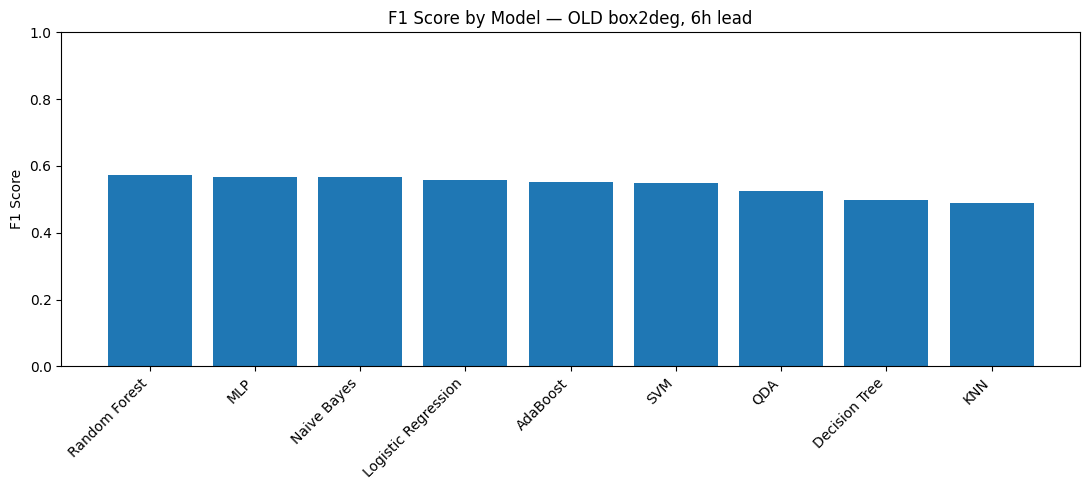

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_f1_6h.png


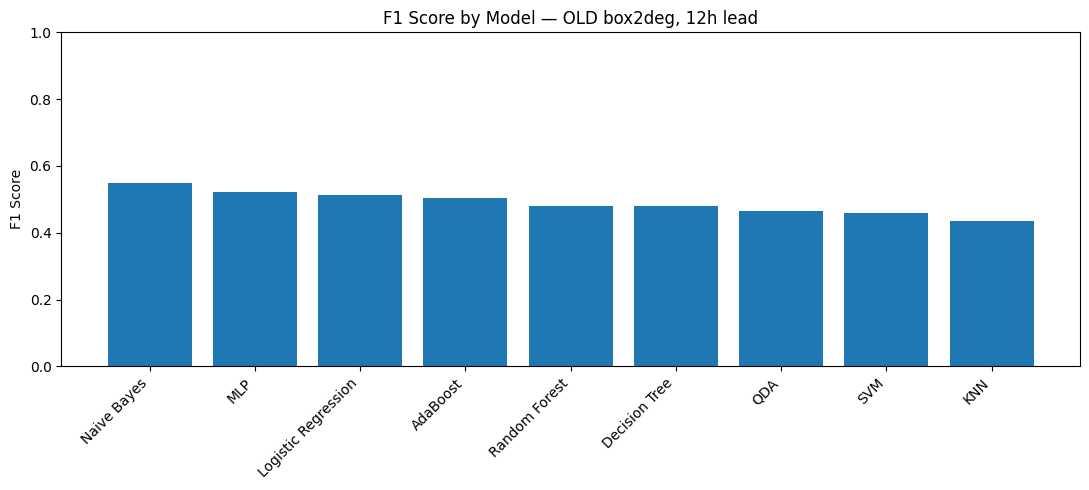

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_f1_12h.png


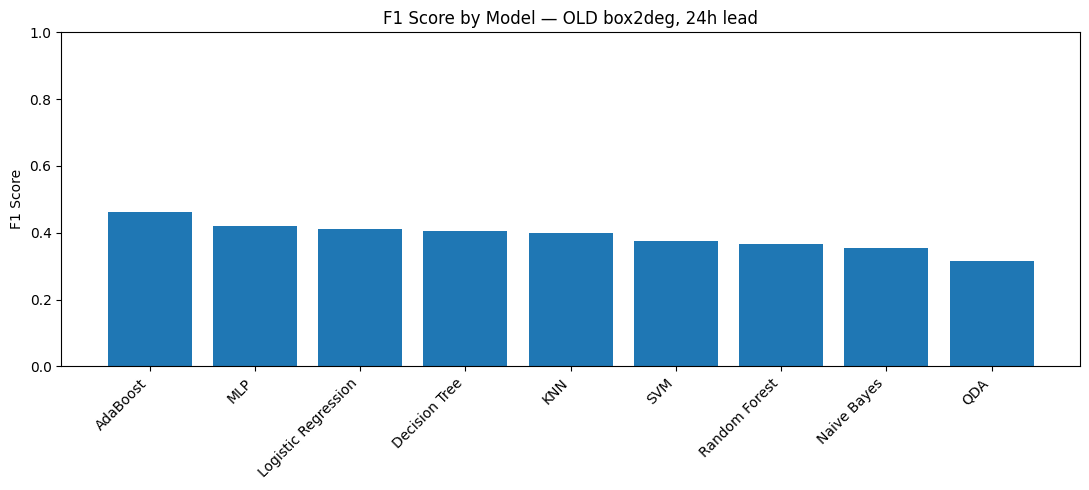

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_f1_24h.png


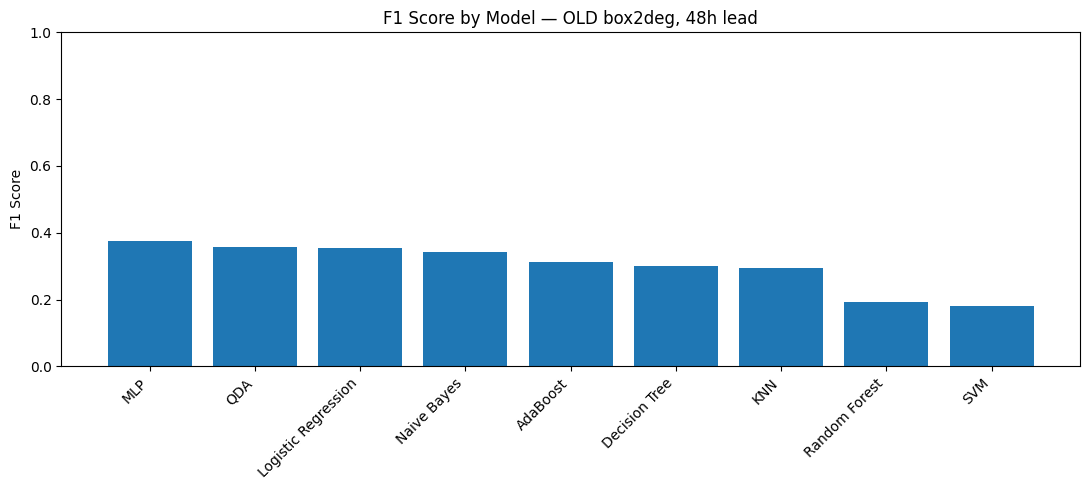

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_f1_48h.png


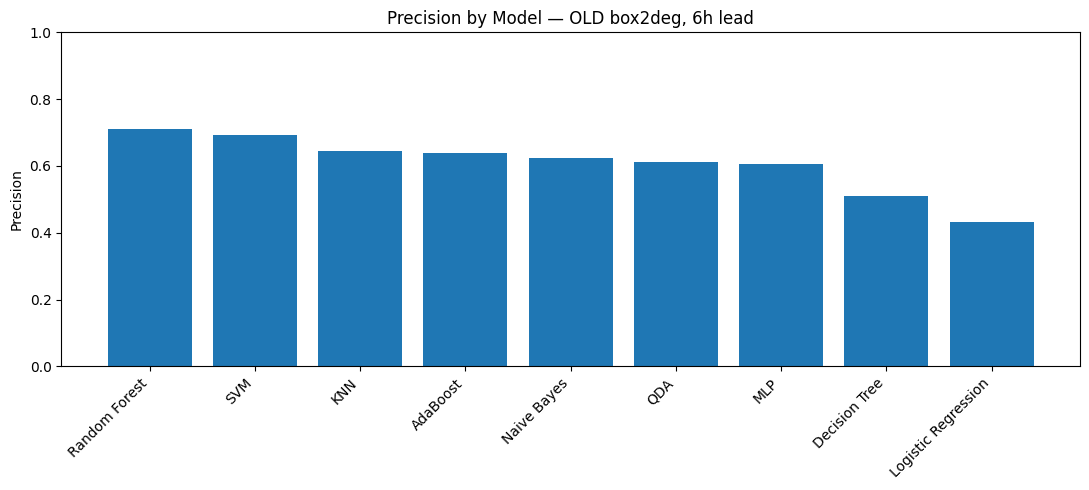

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_precision_6h.png


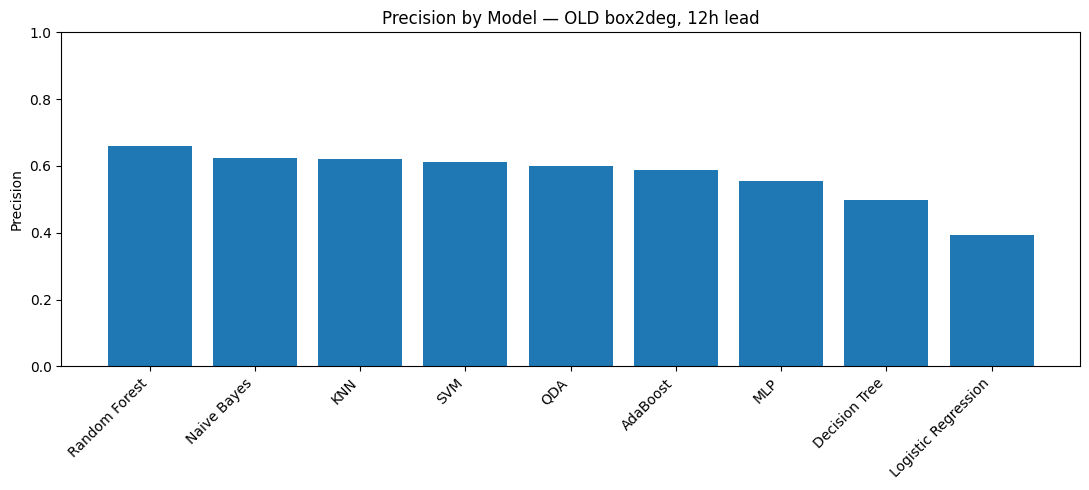

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_precision_12h.png


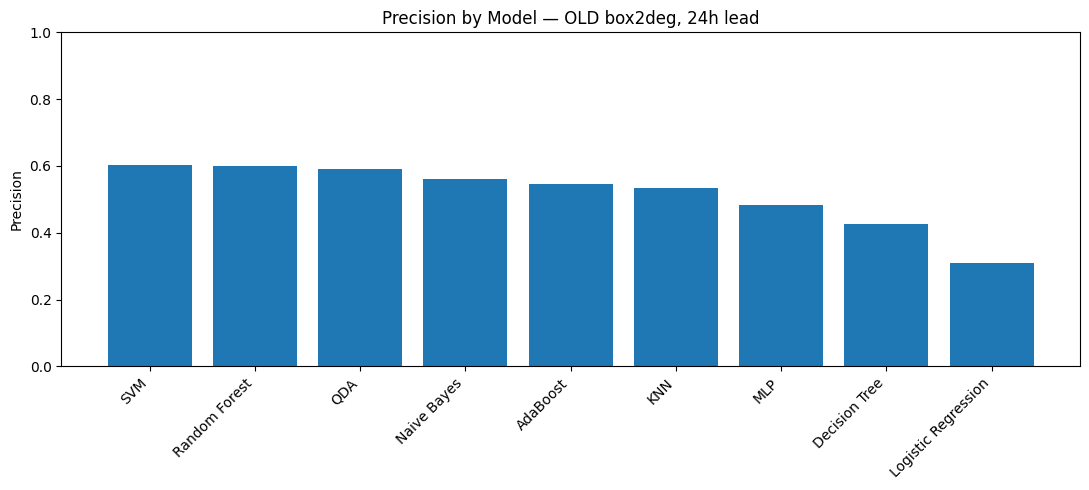

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_precision_24h.png


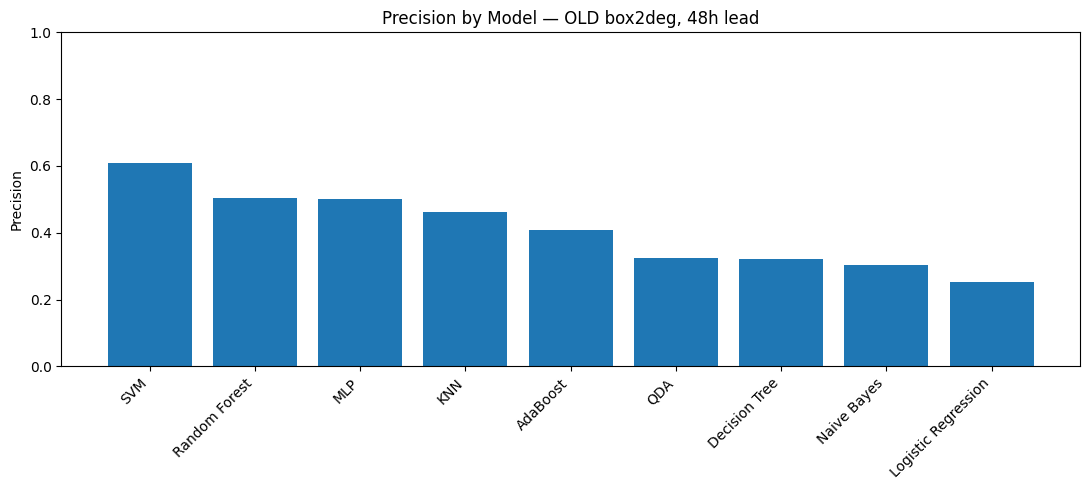

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_precision_48h.png


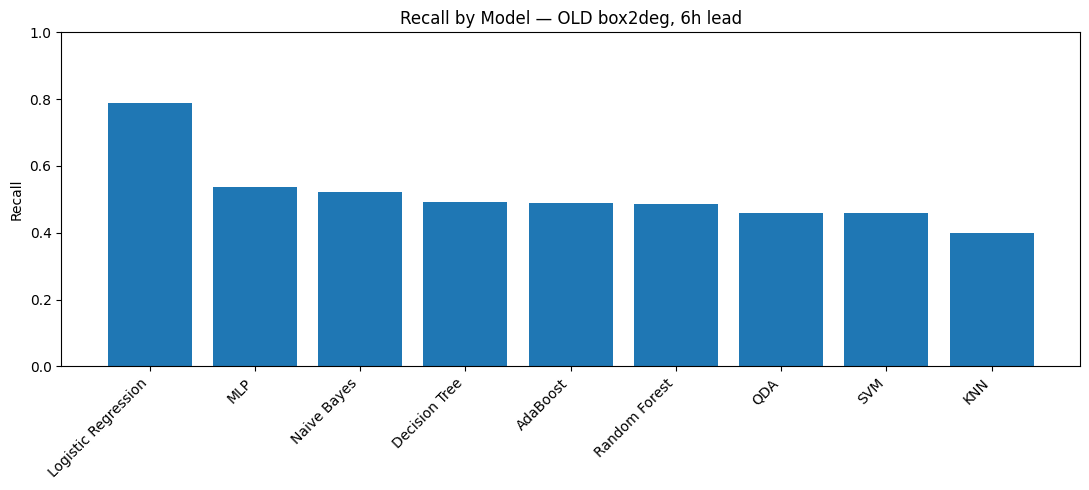

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_recall_6h.png


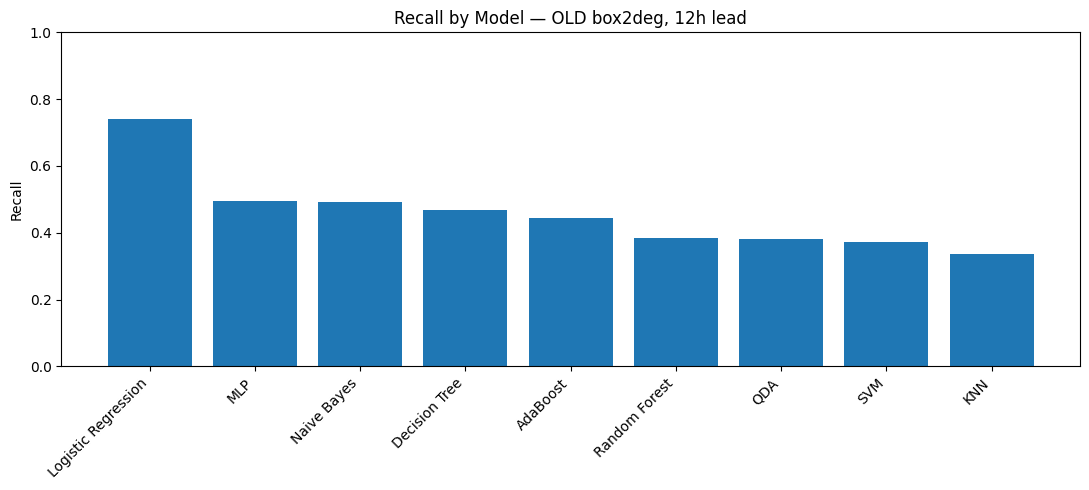

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_recall_12h.png


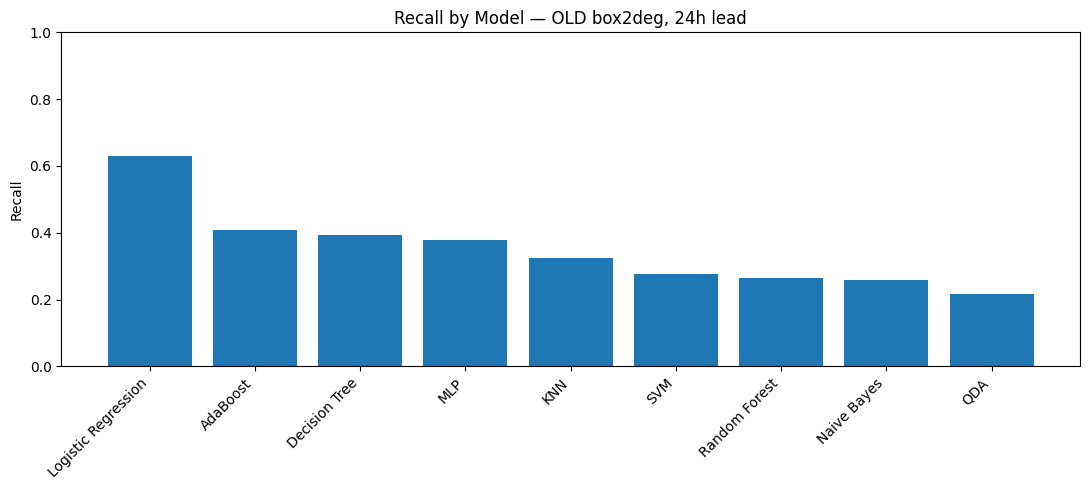

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_recall_24h.png


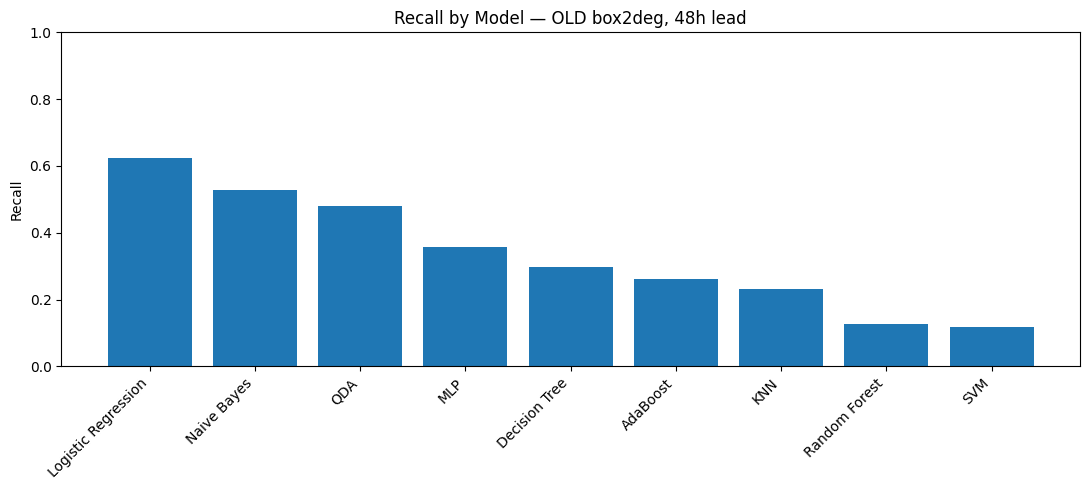

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\bar_recall_48h.png


In [12]:
# ============================================================
# BAR PLOTS FOR F1 / PRECISION / RECALL
# ============================================================

import matplotlib.pyplot as plt

def plot_metric_by_lead(metric_col, ylabel, filename_prefix):
    for L in LEADS:
        sub = cv_summary[cv_summary["lead_h"] == L].copy()
        sub = sub.sort_values(metric_col, ascending=False)

        plt.figure(figsize=(11, 5))
        plt.bar(sub["model"], sub[metric_col])
        plt.xticks(rotation=45, ha="right")
        plt.ylabel(ylabel)
        plt.title(f"{ylabel} by Model — {DATASET_NAME.upper()} {LABEL_NAME}, {L}h lead")
        plt.ylim(0, max(1.0, sub[metric_col].max() * 1.15))
        plt.tight_layout()

        out_fp = OUT_DIR / f"{filename_prefix}_{L}h.png"
        plt.savefig(out_fp, dpi=200)
        plt.show()

        print("Saved:", out_fp)

plot_metric_by_lead("f1_mean", "F1 Score", "bar_f1")
plot_metric_by_lead("precision_mean", "Precision", "bar_precision")
plot_metric_by_lead("recall_mean", "Recall", "bar_recall")

In [13]:
# ============================================================
# GPI-ONLY THRESHOLD BASELINE
# ============================================================

def gpi_threshold_baseline(case_csv, lead_h):
    df = pd.read_csv(case_csv)
    df = df.dropna(subset=["gpi"]).copy()

    y = df["y"].astype(int).values
    score = df["gpi"].astype(float).values

    scan = threshold_scan(y, score)

    if len(scan) == 0:
        return pd.DataFrame(), pd.DataFrame()

    best = scan.iloc[[0]].copy()
    best["dataset"] = DATASET_NAME
    best["label"] = LABEL_NAME
    best["lead_h"] = lead_h
    best["model"] = "GPI threshold"

    scan["dataset"] = DATASET_NAME
    scan["label"] = LABEL_NAME
    scan["lead_h"] = lead_h
    scan["model"] = "GPI threshold"

    return scan, best


gpi_scans = []
gpi_bests = []

for L in LEADS:
    case_csv = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

    scan, best = gpi_threshold_baseline(case_csv, L)

    if len(scan) > 0:
        scan.to_csv(OUT_DIR / f"gpi_threshold_scan_{L}h.csv", index=False)
        gpi_scans.append(scan)
        gpi_bests.append(best)

if gpi_bests:
    gpi_best = pd.concat(gpi_bests, ignore_index=True)
    gpi_best.to_csv(OUT_DIR / "gpi_threshold_best_by_lead.csv", index=False)
    display(gpi_best[["lead_h", "model", "threshold", "f1", "precision", "recall", "roc_auc", "pr_auc"]])

,lead_h,model,threshold,f1,precision,recall,roc_auc,pr_auc
0,6,GPI threshold,26.172978,0.602020,0.543796,0.674208,0.842163,0.594254
1,12,GPI threshold,13.059708,0.562500,0.439024,0.782609,0.829210,0.562440
2,24,GPI threshold,18.703836,0.518519,0.480392,0.563218,0.762469,0.465047
3,48,GPI threshold,2.571522,0.424125,0.278061,0.893443,0.677775,0.330614


PLOTTINGGGGG

In [14]:
# ============================================================
# OLD DATASET — PLOT CONFIG
# Loads outputs from ML_CV_2009_2025.ipynb
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import gaussian_kde
from sklearn.metrics import precision_score, recall_score, f1_score

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
DATASET_NAME = "old"
LABEL_NAME = "box2deg"
PERIOD_TAG = "2009_2025"

CASE_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\exactlead_box2deg_case_tables_old_2009_2025_JJASO"
)

OUT_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final"
)

PLOT_DIR = OUT_DIR / "plots_old"
CM_DIR = OUT_DIR / "confusion_matrices_old"
FI_DIR = OUT_DIR / "feature_importance_old"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)
FI_DIR.mkdir(parents=True, exist_ok=True)

LEADS = [6, 12, 24, 48]

FEATURE_COLS = [
    "lon", "lat", "month",
    "area_km2", "tb_mean", "tb_min",
    "speed_kmh", "direction_deg",
    "eta850_abs", "rh600", "wshear_200_850",
    "pi_vmax_ms", "gpi"
]

ID_COLS = [
    "track_id", "time", "centroid_lon", "centroid_lat"
]

# ------------------------------------------------------------
# Load saved ML outputs
# ------------------------------------------------------------
fold_results = pd.read_csv(OUT_DIR / "fold_results_all_models.csv")
oof_all = pd.read_csv(OUT_DIR / "oof_predictions_all_models.csv")
oof_summary = pd.read_csv(OUT_DIR / "oof_summary_default_and_tuned_all_models.csv")
threshold_scans = pd.read_csv(OUT_DIR / "threshold_scans_all_models.csv")

oof_all["time"] = pd.to_datetime(oof_all["time"], errors="coerce", utc=True).dt.tz_convert(None)

print("Loaded:")
print("fold_results:", fold_results.shape)
print("oof_all:", oof_all.shape)
print("oof_summary:", oof_summary.shape)
print("threshold_scans:", threshold_scans.shape)

print("\nAvailable models:")
print(sorted(oof_all["model"].dropna().unique()))

Loaded:
fold_results: (180, 24)
oof_all: (39474, 13)
oof_summary: (72, 16)
threshold_scans: (13193, 15)

Available models:
['AdaBoost', 'Decision Tree', 'KNN', 'Logistic Regression', 'MLP', 'Naive Bayes', 'QDA', 'Random Forest', 'SVM']


In [15]:
# ============================================================
# LOAD OLD CASE TABLES
# ============================================================

datasets = {}

for L in LEADS:
    fp = CASE_DIR / f"{LABEL_NAME}_case_table_{DATASET_NAME}_{L}h.csv"

    if not fp.exists():
        raise FileNotFoundError(fp)

    df = pd.read_csv(fp)
    df["time"] = pd.to_datetime(df["time"], errors="coerce", utc=True).dt.tz_convert(None)
    df["y"] = df["y"].astype(int)

    datasets[L] = df.copy()

    print(f"\nLead {L}h")
    print("Rows:", len(df))
    print("Positive:", int(df["y"].sum()))
    print("Negative:", int((df["y"] == 0).sum()))
    print("Any predictor NaN fraction:", df[FEATURE_COLS].isna().any(axis=1).mean())


Lead 6h
Rows: 1338
Positive: 223
Negative: 1115
Any predictor NaN fraction: 0.577727952167414

Lead 12h
Rows: 1242
Positive: 207
Negative: 1035
Any predictor NaN fraction: 0.5491143317230274

Lead 24h
Rows: 1050
Positive: 175
Negative: 875
Any predictor NaN fraction: 0.6028571428571429

Lead 48h
Rows: 756
Positive: 126
Negative: 630
Any predictor NaN fraction: 0.6309523809523809


In [16]:
# ============================================================
# SUMMARY TABLES
# ============================================================

metric_cols = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

# If cv_summary already exists, load it. Otherwise rebuild from fold_results.
cv_summary_fp = OUT_DIR / "cv_summary_mean_std_all_models.csv"

if cv_summary_fp.exists():
    cv_summary = pd.read_csv(cv_summary_fp)
else:
    summary_rows = []

    for (lead_h, model), g in fold_results.groupby(["lead_h", "model"]):
        row = {
            "dataset": DATASET_NAME,
            "label": LABEL_NAME,
            "lead_h": lead_h,
            "model": model,
            "folds": g["fold"].nunique(),
            "samples_mean": g["test_n"].mean(),
            "test_pos_mean": g["test_pos"].mean(),
            "test_neg_mean": g["test_neg"].mean(),
        }

        for metric in metric_cols:
            row[f"{metric}_mean"] = g[metric].mean()
            row[f"{metric}_std"] = g[metric].std()

        summary_rows.append(row)

    cv_summary = pd.DataFrame(summary_rows)
    cv_summary.to_csv(cv_summary_fp, index=False)

cv_summary = cv_summary.sort_values(["lead_h", "f1_mean"], ascending=[True, False]).reset_index(drop=True)

ranked_table = cv_summary[
    [
        "lead_h", "model",
        "precision_mean", "recall_mean", "f1_mean",
        "roc_auc_mean", "pr_auc_mean"
    ]
].copy()

ranked_table = ranked_table.rename(columns={
    "precision_mean": "precision",
    "recall_mean": "recall",
    "f1_mean": "f1",
    "roc_auc_mean": "roc_auc",
    "pr_auc_mean": "pr_auc",
})

ranked_table.to_csv(OUT_DIR / "model_performance_ranked_by_lead_old.csv", index=False)

best_by_lead = (
    ranked_table
    .sort_values(["lead_h", "f1"], ascending=[True, False])
    .groupby("lead_h", as_index=False)
    .first()
)

best_by_lead.to_csv(OUT_DIR / "best_model_by_lead_old.csv", index=False)

print("\nRanked table:")
display(ranked_table)

print("\nBest model by lead:")
display(best_by_lead)


Ranked table:


,lead_h,model,precision,recall,f1,roc_auc,pr_auc
0,6,Random Forest,0.709113,0.485514,0.573616,0.913459,0.689244
1,6,MLP,0.606092,0.537561,0.567048,0.862735,0.589701
2,6,Naive Bayes,0.622934,0.521420,0.565751,0.857036,0.558387
3,6,Logistic Regression,0.432452,0.787388,0.557680,0.859078,0.563711
4,6,AdaBoost,0.638368,0.487916,0.552209,0.893033,0.615704
5,6,SVM,0.691958,0.458491,0.549054,0.889125,0.656097
6,6,QDA,0.612363,0.459750,0.523923,0.860817,0.554479
7,6,Decision Tree,0.509109,0.492446,0.498403,0.699643,0.336848
8,6,KNN,0.643812,0.400154,0.489909,0.800199,0.502049
9,12,Naive Bayes,0.624628,0.491539,0.548814,0.843642,0.543773



Best model by lead:


,lead_h,model,precision,recall,f1,roc_auc,pr_auc
0,6,Random Forest,0.709113,0.485514,0.573616,0.913459,0.689244
1,12,Naive Bayes,0.624628,0.491539,0.548814,0.843642,0.543773
2,24,AdaBoost,0.545091,0.407664,0.462053,0.845128,0.529333
3,48,MLP,0.500164,0.357551,0.375909,0.778961,0.415243


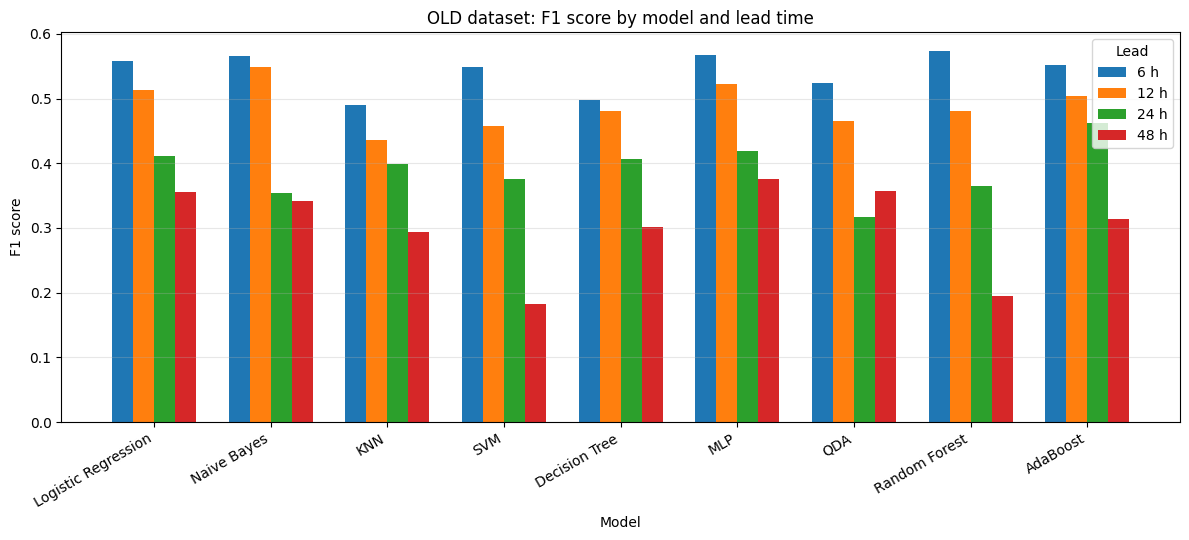

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\plots_old\bar_f1_by_model_lead_old.png


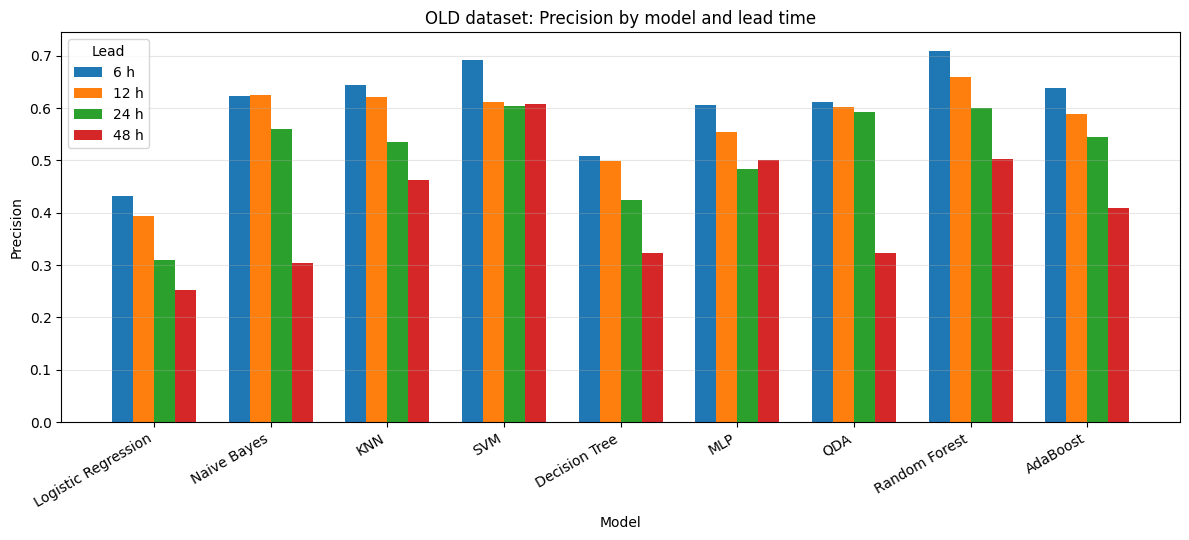

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\plots_old\bar_precision_by_model_lead_old.png


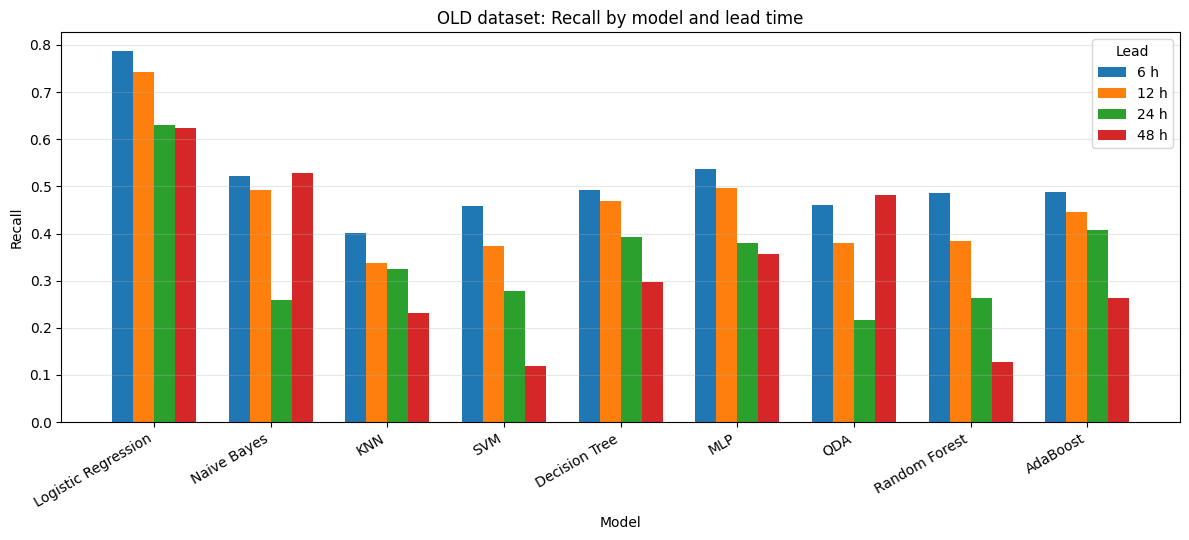

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\plots_old\bar_recall_by_model_lead_old.png


In [17]:
# ============================================================
# GROUPED BAR PLOTS — OLD
# F1, Precision, Recall
# ============================================================

MODEL_ORDER = [
    "Logistic Regression",
    "Naive Bayes",
    "KNN",
    "SVM",
    "Decision Tree",
    "MLP",
    "QDA",
    "Random Forest",
    "AdaBoost",
]

summary_plot = cv_summary.copy()
summary_plot["model"] = pd.Categorical(summary_plot["model"], categories=MODEL_ORDER, ordered=True)
summary_plot = summary_plot.sort_values(["model", "lead_h"]).copy()

lead_order = [6, 12, 24, 48]


def make_bar_metric(metric_col, ylabel, title, outname):
    piv = summary_plot.pivot(index="model", columns="lead_h", values=metric_col)
    piv = piv.reindex(MODEL_ORDER)
    piv = piv[lead_order]

    x = np.arange(len(piv.index))
    width = 0.18

    fig, ax = plt.subplots(figsize=(12, 5.5))

    for i, lead in enumerate(lead_order):
        ax.bar(
            x + (i - 1.5) * width,
            piv[lead],
            width=width,
            label=f"{lead} h"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(piv.index, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Model")
    ax.set_title(title)
    ax.legend(title="Lead")
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(PLOT_DIR / outname, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", PLOT_DIR / outname)


make_bar_metric(
    metric_col="f1_mean",
    ylabel="F1 score",
    title="OLD dataset: F1 score by model and lead time",
    outname="bar_f1_by_model_lead_old.png"
)

make_bar_metric(
    metric_col="precision_mean",
    ylabel="Precision",
    title="OLD dataset: Precision by model and lead time",
    outname="bar_precision_by_model_lead_old.png"
)

make_bar_metric(
    metric_col="recall_mean",
    ylabel="Recall",
    title="OLD dataset: Recall by model and lead time",
    outname="bar_recall_by_model_lead_old.png"
)

Top models: ['MLP', 'Logistic Regression', 'AdaBoost', 'Naive Bayes']


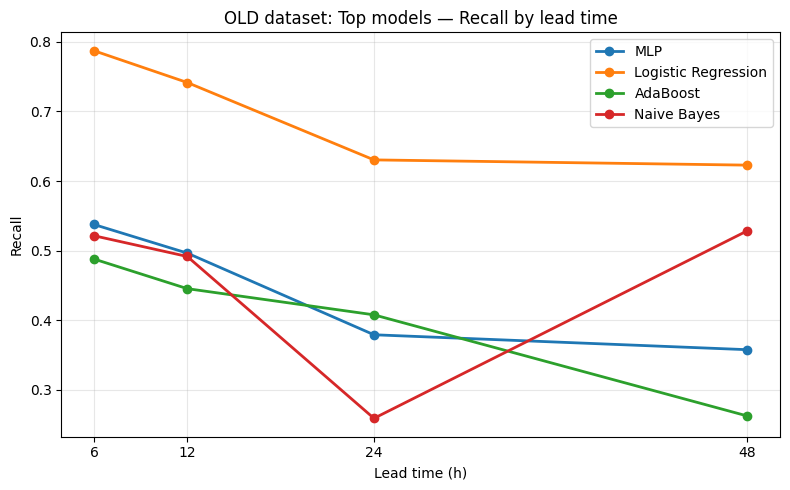

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\plots_old\top_models_recall_old.png


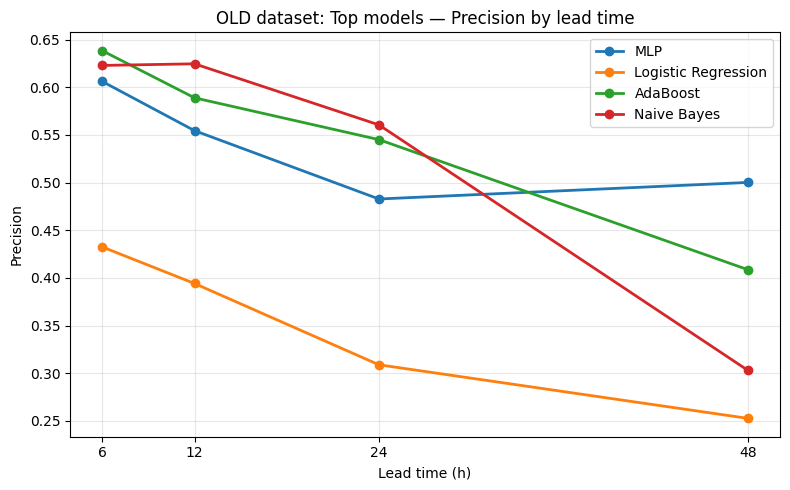

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\plots_old\top_models_precision_old.png


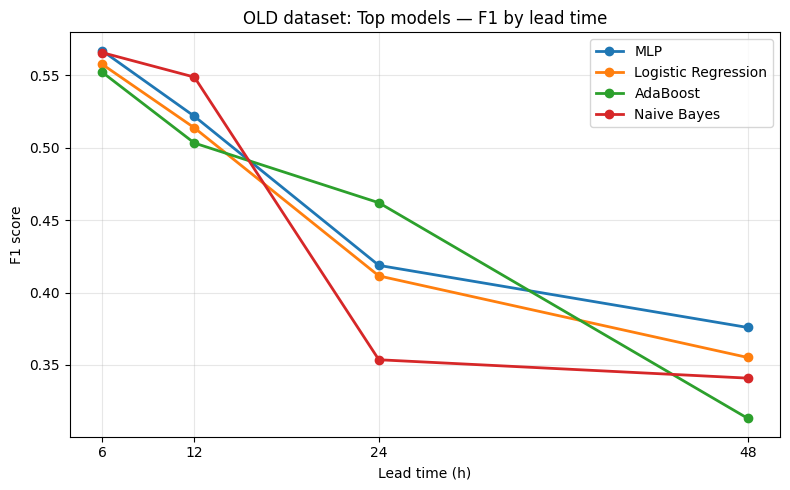

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\plots_old\top_models_f1_old.png


In [18]:
# ============================================================
# LINE PLOTS — TOP MODELS
# ============================================================

top_models = (
    cv_summary.groupby("model")["f1_mean"]
    .mean()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

print("Top models:", top_models)


def make_line_top(metric_col, ylabel, title, outname):
    fig, ax = plt.subplots(figsize=(8, 5))

    for model in top_models:
        sub = cv_summary[cv_summary["model"] == model].sort_values("lead_h")
        ax.plot(
            sub["lead_h"],
            sub[metric_col],
            marker="o",
            linewidth=2,
            label=model
        )

    ax.set_xticks(LEADS)
    ax.set_xlabel("Lead time (h)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(PLOT_DIR / outname, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", PLOT_DIR / outname)


make_line_top(
    metric_col="recall_mean",
    ylabel="Recall",
    title="OLD dataset: Top models — Recall by lead time",
    outname="top_models_recall_old.png"
)

make_line_top(
    metric_col="precision_mean",
    ylabel="Precision",
    title="OLD dataset: Top models — Precision by lead time",
    outname="top_models_precision_old.png"
)

make_line_top(
    metric_col="f1_mean",
    ylabel="F1 score",
    title="OLD dataset: Top models — F1 by lead time",
    outname="top_models_f1_old.png"
)

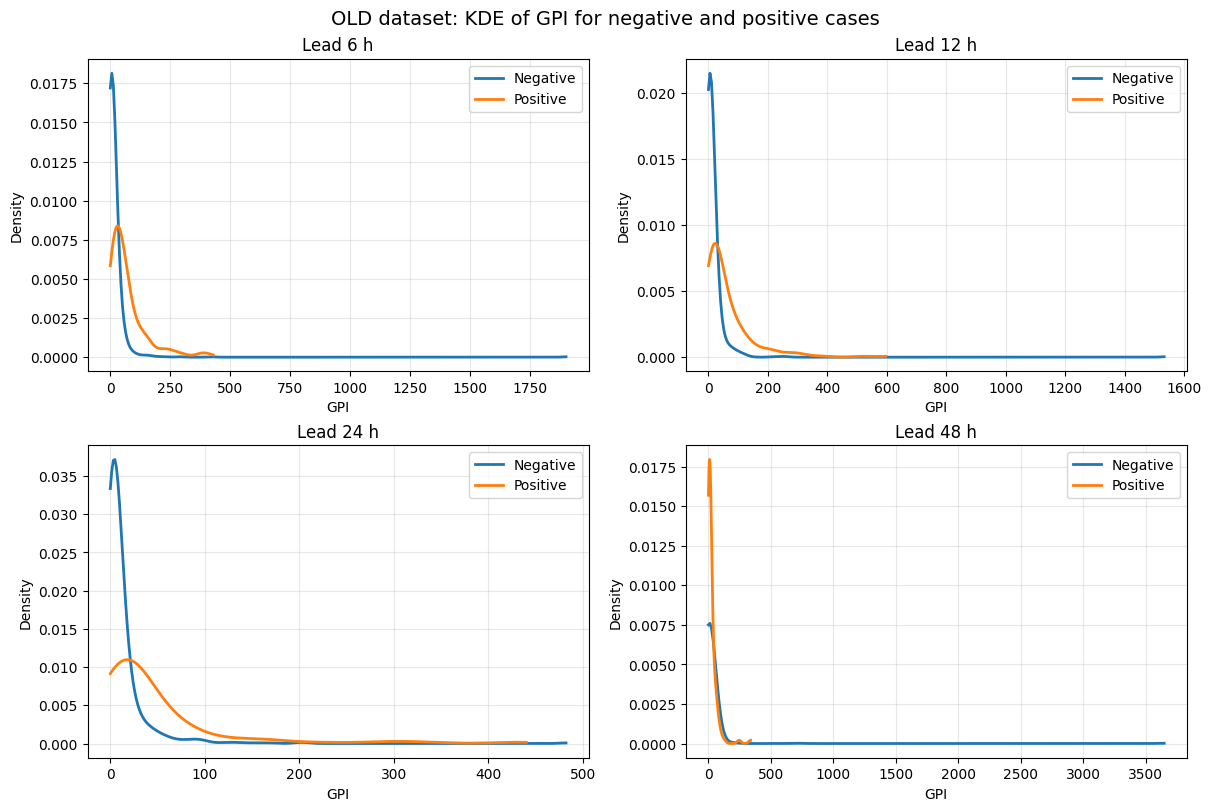

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\plots_old\gpi_kde_positive_negative_old.png


In [19]:
# ============================================================
# GPI KDE — OLD
# Positive vs Negative by lead
# ============================================================

GPI_COL = "gpi"

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

for ax, lead in zip(axes, LEADS):
    df = datasets[lead].copy()
    df = df.dropna(subset=[GPI_COL])

    neg = df.loc[df["y"] == 0, GPI_COL].astype(float).values
    pos = df.loc[df["y"] == 1, GPI_COL].astype(float).values

    if len(neg) > 5 and np.nanmax(neg) > np.nanmin(neg):
        xs = np.linspace(np.nanmin(neg), np.nanmax(neg), 300)
        kde = gaussian_kde(neg)
        ax.plot(xs, kde(xs), linewidth=2, label="Negative")

    if len(pos) > 5 and np.nanmax(pos) > np.nanmin(pos):
        xs = np.linspace(np.nanmin(pos), np.nanmax(pos), 300)
        kde = gaussian_kde(pos)
        ax.plot(xs, kde(xs), linewidth=2, label="Positive")

    ax.set_title(f"Lead {lead} h")
    ax.set_xlabel("GPI")
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("OLD dataset: KDE of GPI for negative and positive cases", fontsize=14)
plt.savefig(PLOT_DIR / "gpi_kde_positive_negative_old.png", dpi=220, bbox_inches="tight")
plt.show()

print("Saved:", PLOT_DIR / "gpi_kde_positive_negative_old.png")

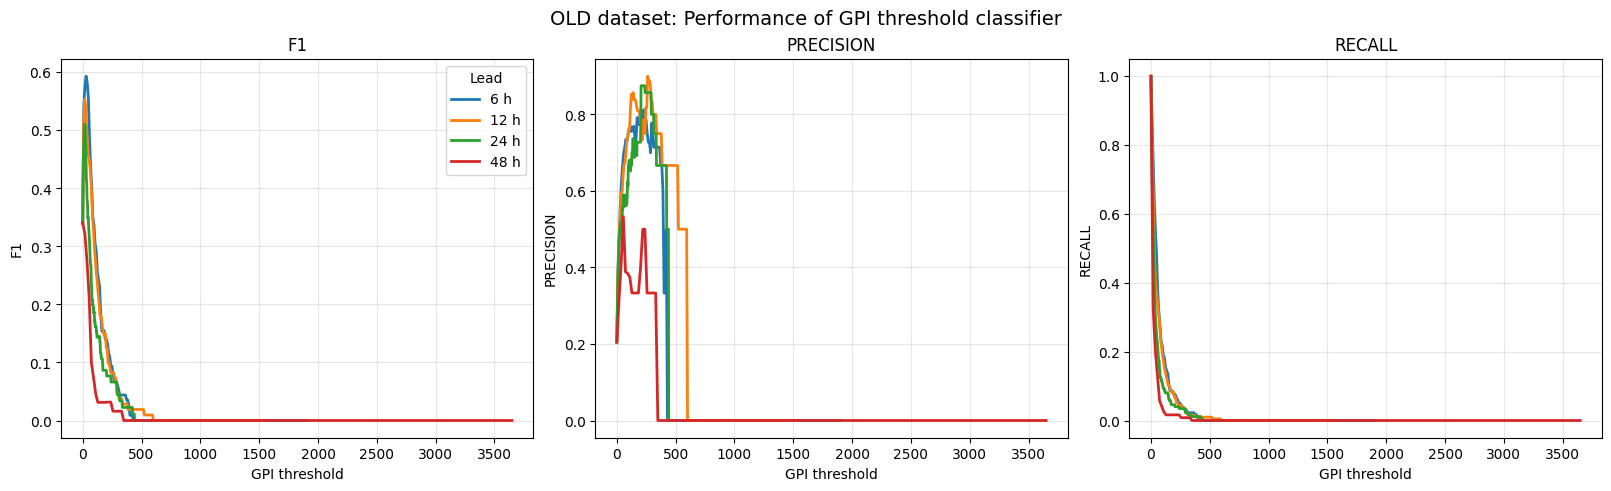


Best GPI threshold by lead:


,lead_h,threshold,f1,precision,recall
0,6,28.674762,0.593220,0.557769,0.633484
1,12,15.407792,0.553903,0.450151,0.719807
2,24,14.533306,0.510539,0.430830,0.626437
3,48,0.000000,0.340782,0.205387,1.000000


In [20]:
# ============================================================
# GPI THRESHOLD CLASSIFIER — OLD
# F1 / Precision / Recall vs GPI threshold
# ============================================================

rows = []

for lead in LEADS:
    df = datasets[lead].copy()
    df = df.dropna(subset=[GPI_COL])

    y_true = df["y"].astype(int).values
    gpi = df[GPI_COL].astype(float).values

    if len(df) == 0:
        continue

    thresholds = np.linspace(np.nanmin(gpi), np.nanmax(gpi), 200)

    for thr in thresholds:
        y_pred = (gpi >= thr).astype(int)

        rows.append({
            "lead_h": lead,
            "threshold": thr,
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        })

gpi_perf = pd.DataFrame(rows)
gpi_perf.to_csv(OUT_DIR / "gpi_threshold_performance_old.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)
metric_list = ["f1", "precision", "recall"]

for ax, metric in zip(axes, metric_list):
    for lead in LEADS:
        sub = gpi_perf[gpi_perf["lead_h"] == lead]
        ax.plot(sub["threshold"], sub[metric], linewidth=2, label=f"{lead} h")

    ax.set_title(metric.upper())
    ax.set_xlabel("GPI threshold")
    ax.set_ylabel(metric.upper())
    ax.grid(True, alpha=0.3)

axes[0].legend(title="Lead")
fig.suptitle("OLD dataset: Performance of GPI threshold classifier", fontsize=14)
plt.savefig(PLOT_DIR / "gpi_threshold_classifier_performance_old.png", dpi=220, bbox_inches="tight")
plt.show()

best_gpi = (
    gpi_perf.sort_values(["lead_h", "f1"], ascending=[True, False])
    .groupby("lead_h", as_index=False)
    .first()
)

best_gpi.to_csv(OUT_DIR / "best_gpi_threshold_by_lead_old.csv", index=False)

print("\nBest GPI threshold by lead:")
display(best_gpi[["lead_h", "threshold", "f1", "precision", "recall"]])

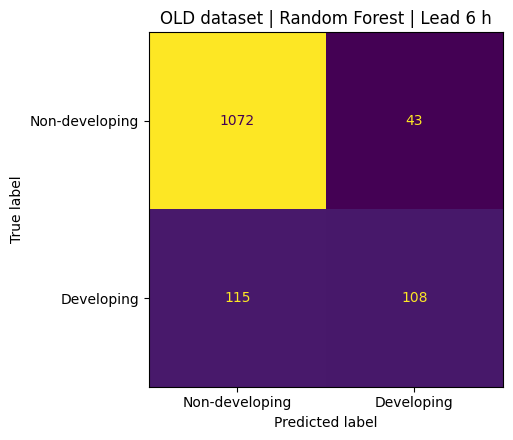

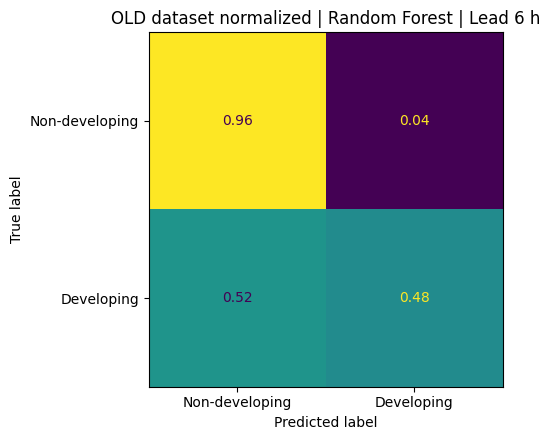

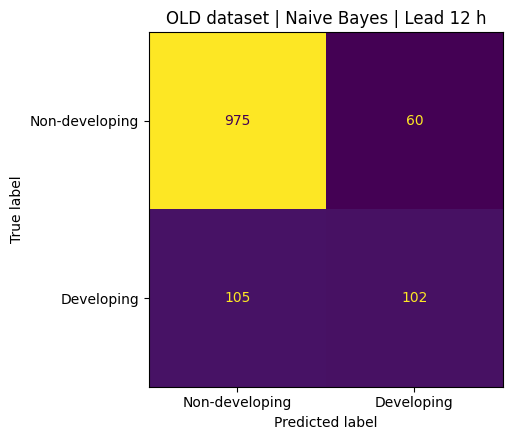

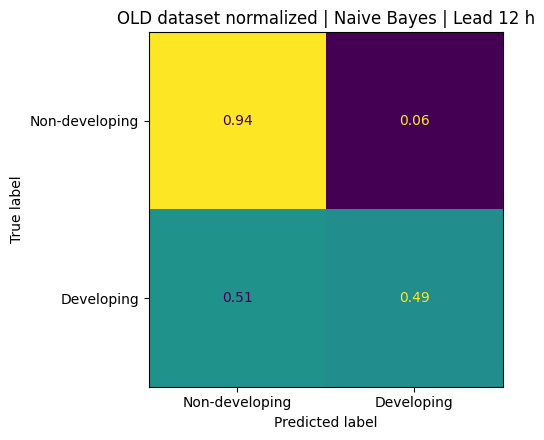

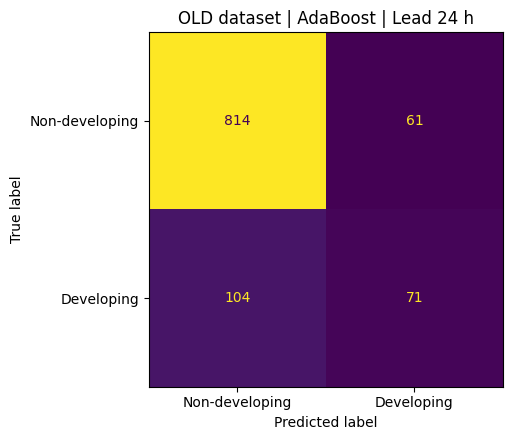

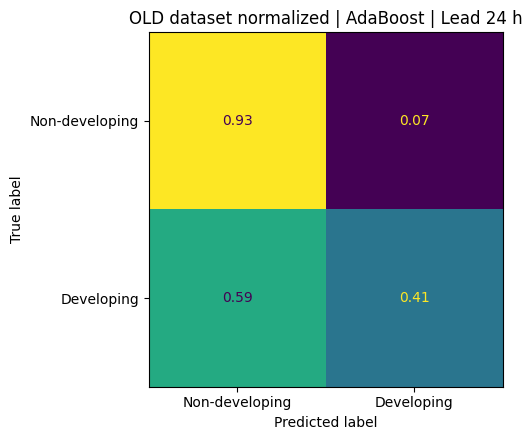

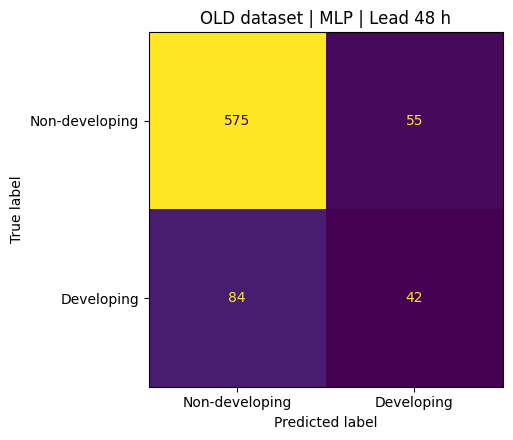

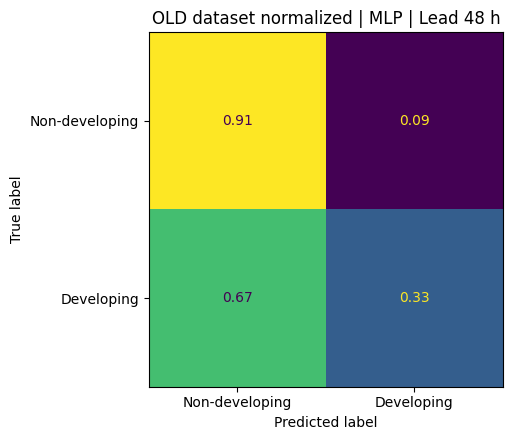

,lead_h,model,tn,fp,fn,tp,total
0,6,Random Forest,1072,43,115,108,1338
1,12,Naive Bayes,975,60,105,102,1242
2,24,AdaBoost,814,61,104,71,1050
3,48,MLP,575,55,84,42,756


In [21]:
# ============================================================
# CONFUSION MATRICES — OLD BEST MODEL PER LEAD
# Uses OOF predictions from CV
# ============================================================

cm_rows = []

for _, row in best_by_lead.iterrows():
    lead = int(row["lead_h"])
    model_name = row["model"]

    sub = oof_all[
        (oof_all["lead_h"] == lead)
        & (oof_all["model"] == model_name)
    ].copy()

    y_true = sub["y_true"].astype(int).values

    # Use default prediction if available
    if "y_pred_default" in sub.columns:
        y_pred = sub["y_pred_default"].astype(int).values
    elif "y_pred" in sub.columns:
        y_pred = sub["y_pred"].astype(int).values
    else:
        y_pred = (sub["y_score"].astype(float).values >= 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    cm_rows.append({
        "lead_h": lead,
        "model": model_name,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "total": int(cm.sum()),
    })

    fig, ax = plt.subplots(figsize=(5.5, 4.5))

    ConfusionMatrixDisplay(
        cm,
        display_labels=["Non-developing", "Developing"]
    ).plot(ax=ax, colorbar=False, values_format="d")

    ax.set_title(f"OLD dataset | {model_name} | Lead {lead} h")
    plt.tight_layout()

    safe_model = model_name.replace(" ", "_").replace("/", "_")
    out_png = CM_DIR / f"confusion_matrix_old_{safe_model}_{lead}h.png"

    plt.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()

    # Normalized
    cm_norm = confusion_matrix(y_true, y_pred, labels=[0, 1], normalize="true")

    fig, ax = plt.subplots(figsize=(5.5, 4.5))

    ConfusionMatrixDisplay(
        cm_norm,
        display_labels=["Non-developing", "Developing"]
    ).plot(ax=ax, colorbar=False, values_format=".2f")

    ax.set_title(f"OLD dataset normalized | {model_name} | Lead {lead} h")
    plt.tight_layout()

    out_png_norm = CM_DIR / f"confusion_matrix_old_normalized_{safe_model}_{lead}h.png"

    plt.savefig(out_png_norm, dpi=220, bbox_inches="tight")
    plt.show()

cm_table = pd.DataFrame(cm_rows)
cm_table.to_csv(CM_DIR / "confusion_matrix_values_best_models_old.csv", index=False)

cm_table

Using existing oof_all from memory.
OOF time range: 2009-06-01 00:00:00 to 2025-10-30 06:00:00
OOF years: 2009 - 2025

Available models in oof_all:
['AdaBoost', 'Decision Tree', 'KNN', 'Logistic Regression', 'MLP', 'Naive Bayes', 'QDA', 'Random Forest', 'SVM']

Models used:
['SVM', 'AdaBoost', 'Random Forest', 'Logistic Regression']

SVM | rows = 1338

AdaBoost | rows = 1338

Random Forest | rows = 1338

Logistic Regression | rows = 1338


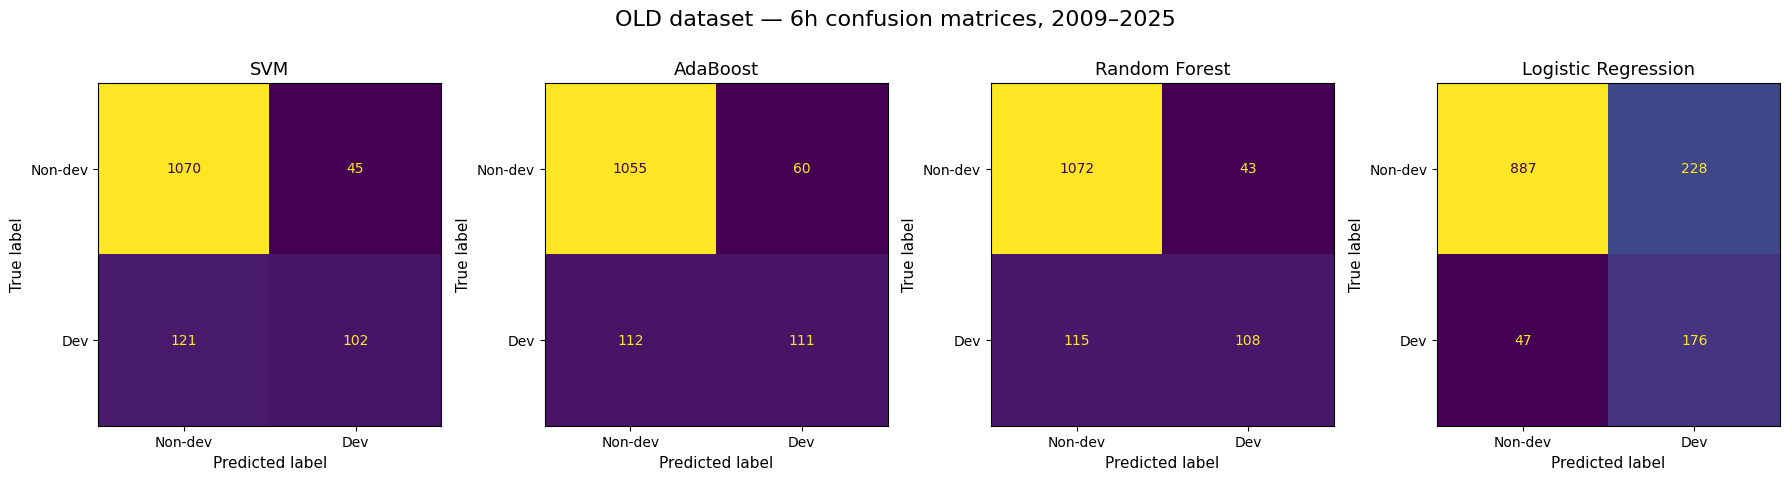


Saved raw-count figure:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_UPDATED\confusion_matrices\combined_figures\old_2009_2025_6h_confusion_matrices_1x4_counts_SVM_AdaBoost_RandomForest_Logistic.png

Saved raw-count values:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_UPDATED\confusion_matrices\combined_figures\old_2009_2025_6h_confusion_matrix_values_counts.csv


,dataset,period,lead_h,model,tn,fp,fn,tp,total
0,old,2009-2025,6,SVM,1070,45,121,102,1338
1,old,2009-2025,6,AdaBoost,1055,60,112,111,1338
2,old,2009-2025,6,Random Forest,1072,43,115,108,1338
3,old,2009-2025,6,Logistic Regression,887,228,47,176,1338


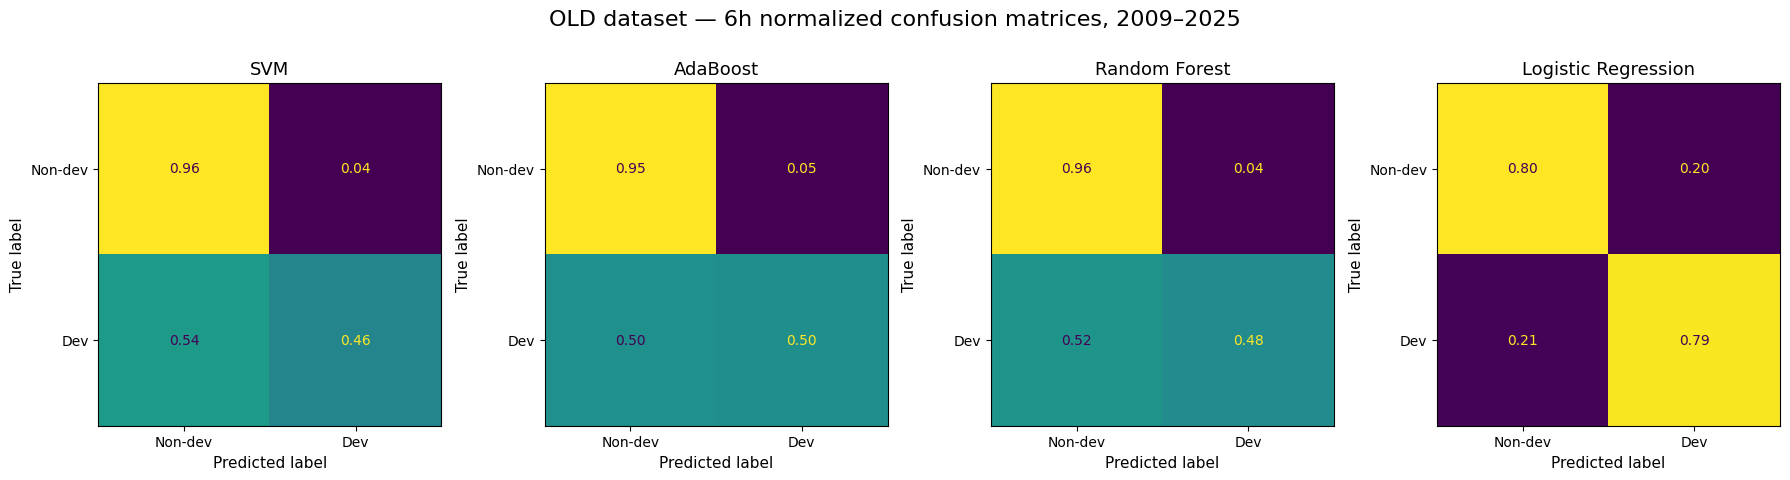


Saved normalized figure:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_UPDATED\confusion_matrices\combined_figures\old_2009_2025_6h_confusion_matrices_1x4_normalized_SVM_AdaBoost_RandomForest_Logistic.png

Saved normalized values:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_UPDATED\confusion_matrices\combined_figures\old_2009_2025_6h_confusion_matrix_values_normalized.csv


,dataset,period,lead_h,model,tn,fp,fn,tp,true_nondev_correct_rate,false_alarm_rate,miss_rate,true_dev_detection_rate
0,old,2009-2025,6,SVM,1070,45,121,102,0.959641,0.040359,0.542601,0.457399
1,old,2009-2025,6,AdaBoost,1055,60,112,111,0.946188,0.053812,0.502242,0.497758
2,old,2009-2025,6,Random Forest,1072,43,115,108,0.961435,0.038565,0.515695,0.484305
3,old,2009-2025,6,Logistic Regression,887,228,47,176,0.795516,0.204484,0.210762,0.789238


In [31]:
# ============================================================
# OLD — 6H CONFUSION MATRICES, 2009–2025 UPDATED
# Models: SVM, AdaBoost, RandomForest, Logistic
# Uses OOF predictions from 5-fold CV
#
# Output:
#   1. Non-normalized / raw-count 1x4 figure
#   2. Normalized 1x4 figure
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ============================================================
# PATHS
# ============================================================

OUT_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_UPDATED"
)

CM_DIR = OUT_DIR / "confusion_matrices"
CM_DIR.mkdir(parents=True, exist_ok=True)

OUT_ONEFIG_DIR = CM_DIR / "combined_figures"
OUT_ONEFIG_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD OOF PREDICTIONS IF NEEDED
# ============================================================

OOF_CANDIDATES = [
    OUT_DIR / "oof_predictions_allmodels_old.csv",
    OUT_DIR / "oof_predictions_all_models.csv",
    OUT_DIR / "oof_predictions_allmodels.csv",
]

if "oof_all" not in globals():
    found = None

    for fp in OOF_CANDIDATES:
        if fp.exists():
            found = fp
            break

    if found is None:
        raise FileNotFoundError(
            "No OOF prediction file found. Checked:\n"
            + "\n".join(str(fp) for fp in OOF_CANDIDATES)
        )

    print("Loading OOF predictions from:")
    print(found)

    oof_all = pd.read_csv(found)

else:
    print("Using existing oof_all from memory.")

# ============================================================
# SETTINGS
# ============================================================

LEAD = 6

# Your OLD ML may use either "Random Forest" or "RandomForest",
# and either "Logistic Regression" or "Logistic".
MODEL_CANDIDATES = {
    "SVM": ["SVM"],
    "AdaBoost": ["AdaBoost"],
    "Random Forest": ["Random Forest", "RandomForest"],
    "Logistic Regression": ["Logistic Regression", "Logistic"],
}

# ============================================================
# PREPARE OOF DATA
# ============================================================

oof_plot = oof_all.copy()

if "time" in oof_plot.columns:
    oof_plot["time"] = (
        pd.to_datetime(oof_plot["time"], errors="coerce", utc=True)
        .dt.tz_convert(None)
    )

    # Keep full 2009–2025 period
    oof_plot = oof_plot[
        oof_plot["time"].dt.year.between(2009, 2025)
    ].copy()

    print("OOF time range:", oof_plot["time"].min(), "to", oof_plot["time"].max())
    print("OOF years:", oof_plot["time"].dt.year.min(), "-", oof_plot["time"].dt.year.max())

available_models = sorted(oof_plot["model"].dropna().unique())

print("\nAvailable models in oof_all:")
print(available_models)

# Resolve actual model names in your OOF file
MODELS_6H = []

for display_name, candidates in MODEL_CANDIDATES.items():
    found = None

    for c in candidates:
        if c in available_models:
            found = c
            break

    if found is None:
        raise ValueError(
            f"Could not find model for {display_name}.\n"
            f"Tried: {candidates}\n"
            f"Available models: {available_models}"
        )

    MODELS_6H.append(found)

print("\nModels used:")
print(MODELS_6H)

# ============================================================
# HELPER: GET PREDICTION COLUMN
# ============================================================

def get_prediction_array(sub):
    if "y_pred" in sub.columns:
        return sub["y_pred"].astype(int).values

    if "y_pred_default" in sub.columns:
        return sub["y_pred_default"].astype(int).values

    if "y_prob" in sub.columns:
        return (sub["y_prob"].astype(float).values >= 0.5).astype(int)

    if "y_score" in sub.columns:
        return (sub["y_score"].astype(float).values >= 0.5).astype(int)

    raise ValueError(
        "No prediction column found. Need one of: "
        "y_pred, y_pred_default, y_prob, y_score."
    )

# ============================================================
# 1) NON-NORMALIZED / RAW-COUNT CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes = axes.flatten()

cm_rows_count = []

for ax, model_name in zip(axes, MODELS_6H):

    sub = oof_plot[
        (oof_plot["lead_h"] == LEAD)
        & (oof_plot["model"] == model_name)
    ].copy()

    print(f"\n{model_name} | rows = {len(sub)}")

    if len(sub) == 0:
        ax.set_axis_off()
        ax.set_title(f"{model_name}\nNo data")
        continue

    y_true = sub["y_true"].astype(int).values
    y_pred = get_prediction_array(sub)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    cm_rows_count.append({
        "dataset": "old",
        "period": "2009-2025",
        "lead_h": LEAD,
        "model": model_name,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "total": int(cm.sum()),
    })

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-dev", "Dev"]
    ).plot(
        ax=ax,
        colorbar=False,
        values_format="d"
    )

    ax.set_title(model_name, fontsize=13)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)

fig.suptitle("OLD dataset — 6h confusion matrices, 2009–2025", fontsize=16, y=1.03)
plt.tight_layout()

out_png_count = OUT_ONEFIG_DIR / "old_2009_2025_6h_confusion_matrices_1x4_counts_SVM_AdaBoost_RandomForest_Logistic.png"
plt.savefig(out_png_count, dpi=250, bbox_inches="tight")
plt.show()

print("\nSaved raw-count figure:")
print(out_png_count)

cm_count_table = pd.DataFrame(cm_rows_count)

out_csv_count = OUT_ONEFIG_DIR / "old_2009_2025_6h_confusion_matrix_values_counts.csv"
cm_count_table.to_csv(out_csv_count, index=False)

print("\nSaved raw-count values:")
print(out_csv_count)

display(cm_count_table)

# ============================================================
# 2) NORMALIZED CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
axes = axes.flatten()

cm_rows_norm = []

for ax, model_name in zip(axes, MODELS_6H):

    sub = oof_plot[
        (oof_plot["lead_h"] == LEAD)
        & (oof_plot["model"] == model_name)
    ].copy()

    if len(sub) == 0:
        ax.set_axis_off()
        ax.set_title(f"{model_name}\nNo data")
        continue

    y_true = sub["y_true"].astype(int).values
    y_pred = get_prediction_array(sub)

    cm_count = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_norm = confusion_matrix(y_true, y_pred, labels=[0, 1], normalize="true")

    tn, fp, fn, tp = cm_count.ravel()

    cm_rows_norm.append({
        "dataset": "old",
        "period": "2009-2025",
        "lead_h": LEAD,
        "model": model_name,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "true_nondev_correct_rate": cm_norm[0, 0],
        "false_alarm_rate": cm_norm[0, 1],
        "miss_rate": cm_norm[1, 0],
        "true_dev_detection_rate": cm_norm[1, 1],
    })

    ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=["Non-dev", "Dev"]
    ).plot(
        ax=ax,
        colorbar=False,
        values_format=".2f"
    )

    ax.set_title(model_name, fontsize=13)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)

fig.suptitle("OLD dataset — 6h normalized confusion matrices, 2009–2025", fontsize=16, y=1.03)
plt.tight_layout()

out_png_norm = OUT_ONEFIG_DIR / "old_2009_2025_6h_confusion_matrices_1x4_normalized_SVM_AdaBoost_RandomForest_Logistic.png"
plt.savefig(out_png_norm, dpi=250, bbox_inches="tight")
plt.show()

print("\nSaved normalized figure:")
print(out_png_norm)

cm_norm_table = pd.DataFrame(cm_rows_norm)

out_csv_norm = OUT_ONEFIG_DIR / "old_2009_2025_6h_confusion_matrix_values_normalized.csv"
cm_norm_table.to_csv(out_csv_norm, index=False)

print("\nSaved normalized values:")
print(out_csv_norm)

display(cm_norm_table)

Using existing oof_all from memory.
OOF time range: 2009-06-01 00:00:00 to 2025-10-30 06:00:00
OOF years: 2009 - 2025

Available models in oof_all:
['AdaBoost', 'Decision Tree', 'KNN', 'Logistic Regression', 'MLP', 'Naive Bayes', 'QDA', 'Random Forest', 'SVM']

Models used:
['SVM', 'AdaBoost', 'Random Forest', 'Logistic Regression', 'MLP']

SVM | rows = 1338

AdaBoost | rows = 1338

Random Forest | rows = 1338

Logistic Regression | rows = 1338

MLP | rows = 1338


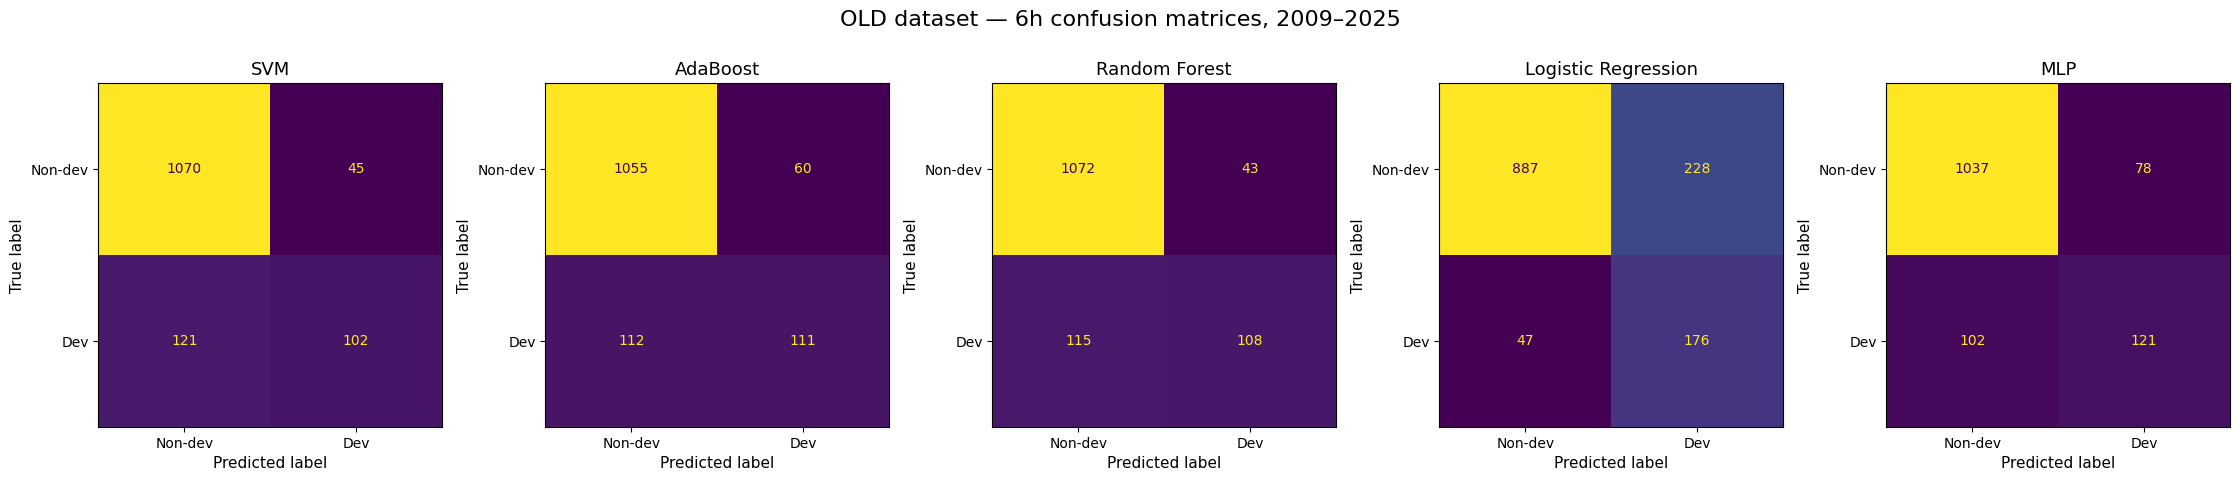


Saved raw-count figure:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_UPDATED\confusion_matrices\combined_figures\old_2009_2025_6h_confusion_matrices_1x5_counts_SVM_AdaBoost_RandomForest_Logistic_MLP.png

Saved raw-count values:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_UPDATED\confusion_matrices\combined_figures\old_2009_2025_6h_confusion_matrix_values_counts_1x5.csv


,dataset,period,lead_h,model,tn,fp,fn,tp,total
0,old,2009-2025,6,SVM,1070,45,121,102,1338
1,old,2009-2025,6,AdaBoost,1055,60,112,111,1338
2,old,2009-2025,6,Random Forest,1072,43,115,108,1338
3,old,2009-2025,6,Logistic Regression,887,228,47,176,1338
4,old,2009-2025,6,MLP,1037,78,102,121,1338


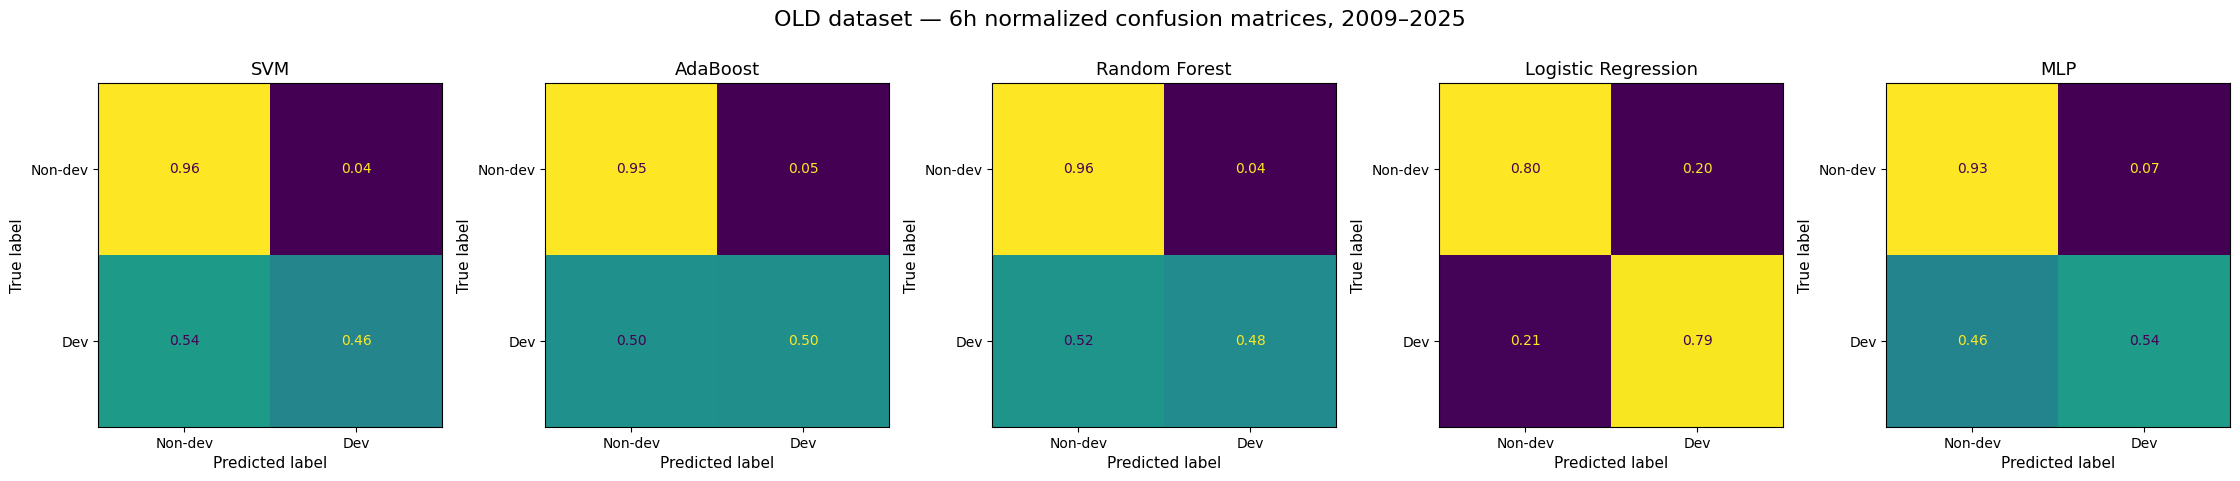


Saved normalized figure:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_UPDATED\confusion_matrices\combined_figures\old_2009_2025_6h_confusion_matrices_1x5_normalized_SVM_AdaBoost_RandomForest_Logistic_MLP.png

Saved normalized values:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_UPDATED\confusion_matrices\combined_figures\old_2009_2025_6h_confusion_matrix_values_normalized_1x5.csv


,dataset,period,lead_h,model,tn,fp,fn,tp,true_nondev_correct_rate,false_alarm_rate,miss_rate,true_dev_detection_rate
0,old,2009-2025,6,SVM,1070,45,121,102,0.959641,0.040359,0.542601,0.457399
1,old,2009-2025,6,AdaBoost,1055,60,112,111,0.946188,0.053812,0.502242,0.497758
2,old,2009-2025,6,Random Forest,1072,43,115,108,0.961435,0.038565,0.515695,0.484305
3,old,2009-2025,6,Logistic Regression,887,228,47,176,0.795516,0.204484,0.210762,0.789238
4,old,2009-2025,6,MLP,1037,78,102,121,0.930045,0.069955,0.457399,0.542601


In [33]:
# ============================================================
# OLD — 6H CONFUSION MATRICES, 2009–2025 UPDATED
# Models: SVM, AdaBoost, RandomForest, Logistic, MLP
# Uses OOF predictions from 5-fold CV
#
# Output:
#   1. Non-normalized / raw-count 1x5 figure
#   2. Normalized 1x5 figure
# ============================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ============================================================
# PATHS
# ============================================================

OUT_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_UPDATED"
)

CM_DIR = OUT_DIR / "confusion_matrices"
CM_DIR.mkdir(parents=True, exist_ok=True)

OUT_ONEFIG_DIR = CM_DIR / "combined_figures"
OUT_ONEFIG_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD OOF PREDICTIONS IF NEEDED
# Keeps your original behavior:
# use current oof_all if it already exists in memory.
# ============================================================

OOF_CANDIDATES = [
    OUT_DIR / "oof_predictions_allmodels_old.csv",
    OUT_DIR / "oof_predictions_all_models.csv",
    OUT_DIR / "oof_predictions_allmodels.csv",
]

if "oof_all" not in globals():
    found = None

    for fp in OOF_CANDIDATES:
        if fp.exists():
            found = fp
            break

    if found is None:
        raise FileNotFoundError(
            "No OOF prediction file found. Checked:\n"
            + "\n".join(str(fp) for fp in OOF_CANDIDATES)
        )

    print("Loading OOF predictions from:")
    print(found)

    oof_all = pd.read_csv(found)

else:
    print("Using existing oof_all from memory.")

# ============================================================
# SETTINGS
# ============================================================

LEAD = 6

MODEL_CANDIDATES = {
    "SVM": ["SVM"],
    "AdaBoost": ["AdaBoost"],
    "Random Forest": ["Random Forest", "RandomForest"],
    "Logistic Regression": ["Logistic Regression", "Logistic"],
    "MLP": ["MLP"],
}

# ============================================================
# PREPARE OOF DATA
# ============================================================

oof_plot = oof_all.copy()

if "time" in oof_plot.columns:
    oof_plot["time"] = (
        pd.to_datetime(oof_plot["time"], errors="coerce", utc=True)
        .dt.tz_convert(None)
    )

    # Keep full 2009–2025 period
    oof_plot = oof_plot[
        oof_plot["time"].dt.year.between(2009, 2025)
    ].copy()

    print("OOF time range:", oof_plot["time"].min(), "to", oof_plot["time"].max())
    print("OOF years:", oof_plot["time"].dt.year.min(), "-", oof_plot["time"].dt.year.max())

available_models = sorted(oof_plot["model"].dropna().unique())

print("\nAvailable models in oof_all:")
print(available_models)

# Resolve actual model names in your OOF file
MODELS_6H = []

for display_name, candidates in MODEL_CANDIDATES.items():
    found = None

    for c in candidates:
        if c in available_models:
            found = c
            break

    if found is None:
        raise ValueError(
            f"Could not find model for {display_name}.\n"
            f"Tried: {candidates}\n"
            f"Available models: {available_models}"
        )

    MODELS_6H.append(found)

print("\nModels used:")
print(MODELS_6H)

# ============================================================
# HELPER: GET PREDICTION COLUMN
# ============================================================

def get_prediction_array(sub):
    if "y_pred" in sub.columns:
        return sub["y_pred"].astype(int).values

    if "y_pred_default" in sub.columns:
        return sub["y_pred_default"].astype(int).values

    if "y_prob" in sub.columns:
        return (sub["y_prob"].astype(float).values >= 0.5).astype(int)

    if "y_score" in sub.columns:
        return (sub["y_score"].astype(float).values >= 0.5).astype(int)

    raise ValueError(
        "No prediction column found. Need one of: "
        "y_pred, y_pred_default, y_prob, y_score."
    )

# ============================================================
# 1) NON-NORMALIZED / RAW-COUNT CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(22.5, 4.5))
axes = axes.flatten()

cm_rows_count = []

for ax, model_name in zip(axes, MODELS_6H):

    sub = oof_plot[
        (oof_plot["lead_h"] == LEAD)
        & (oof_plot["model"] == model_name)
    ].copy()

    print(f"\n{model_name} | rows = {len(sub)}")

    if len(sub) == 0:
        ax.set_axis_off()
        ax.set_title(f"{model_name}\nNo data")
        continue

    y_true = sub["y_true"].astype(int).values
    y_pred = get_prediction_array(sub)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    cm_rows_count.append({
        "dataset": "old",
        "period": "2009-2025",
        "lead_h": LEAD,
        "model": model_name,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "total": int(cm.sum()),
    })

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Non-dev", "Dev"]
    ).plot(
        ax=ax,
        colorbar=False,
        values_format="d"
    )

    ax.set_title(model_name, fontsize=13)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)

fig.suptitle("OLD dataset — 6h confusion matrices, 2009–2025", fontsize=16, y=1.03)
plt.tight_layout()

out_png_count = OUT_ONEFIG_DIR / "old_2009_2025_6h_confusion_matrices_1x5_counts_SVM_AdaBoost_RandomForest_Logistic_MLP.png"
plt.savefig(out_png_count, dpi=250, bbox_inches="tight")
plt.show()

print("\nSaved raw-count figure:")
print(out_png_count)

cm_count_table = pd.DataFrame(cm_rows_count)

out_csv_count = OUT_ONEFIG_DIR / "old_2009_2025_6h_confusion_matrix_values_counts_1x5.csv"
cm_count_table.to_csv(out_csv_count, index=False)

print("\nSaved raw-count values:")
print(out_csv_count)

display(cm_count_table)

# ============================================================
# 2) NORMALIZED CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(1, 5, figsize=(22.5, 4.5))
axes = axes.flatten()

cm_rows_norm = []

for ax, model_name in zip(axes, MODELS_6H):

    sub = oof_plot[
        (oof_plot["lead_h"] == LEAD)
        & (oof_plot["model"] == model_name)
    ].copy()

    if len(sub) == 0:
        ax.set_axis_off()
        ax.set_title(f"{model_name}\nNo data")
        continue

    y_true = sub["y_true"].astype(int).values
    y_pred = get_prediction_array(sub)

    cm_count = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_norm = confusion_matrix(y_true, y_pred, labels=[0, 1], normalize="true")

    tn, fp, fn, tp = cm_count.ravel()

    cm_rows_norm.append({
        "dataset": "old",
        "period": "2009-2025",
        "lead_h": LEAD,
        "model": model_name,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "true_nondev_correct_rate": cm_norm[0, 0],
        "false_alarm_rate": cm_norm[0, 1],
        "miss_rate": cm_norm[1, 0],
        "true_dev_detection_rate": cm_norm[1, 1],
    })

    ConfusionMatrixDisplay(
        confusion_matrix=cm_norm,
        display_labels=["Non-dev", "Dev"]
    ).plot(
        ax=ax,
        colorbar=False,
        values_format=".2f"
    )

    ax.set_title(model_name, fontsize=13)
    ax.set_xlabel("Predicted label", fontsize=11)
    ax.set_ylabel("True label", fontsize=11)

fig.suptitle("OLD dataset — 6h normalized confusion matrices, 2009–2025", fontsize=16, y=1.03)
plt.tight_layout()

out_png_norm = OUT_ONEFIG_DIR / "old_2009_2025_6h_confusion_matrices_1x5_normalized_SVM_AdaBoost_RandomForest_Logistic_MLP.png"
plt.savefig(out_png_norm, dpi=250, bbox_inches="tight")
plt.show()

print("\nSaved normalized figure:")
print(out_png_norm)

cm_norm_table = pd.DataFrame(cm_rows_norm)

out_csv_norm = OUT_ONEFIG_DIR / "old_2009_2025_6h_confusion_matrix_values_normalized_1x5.csv"
cm_norm_table.to_csv(out_csv_norm, index=False)

print("\nSaved normalized values:")
print(out_csv_norm)

display(cm_norm_table)

Feature importance: Random Forest, lead 6h


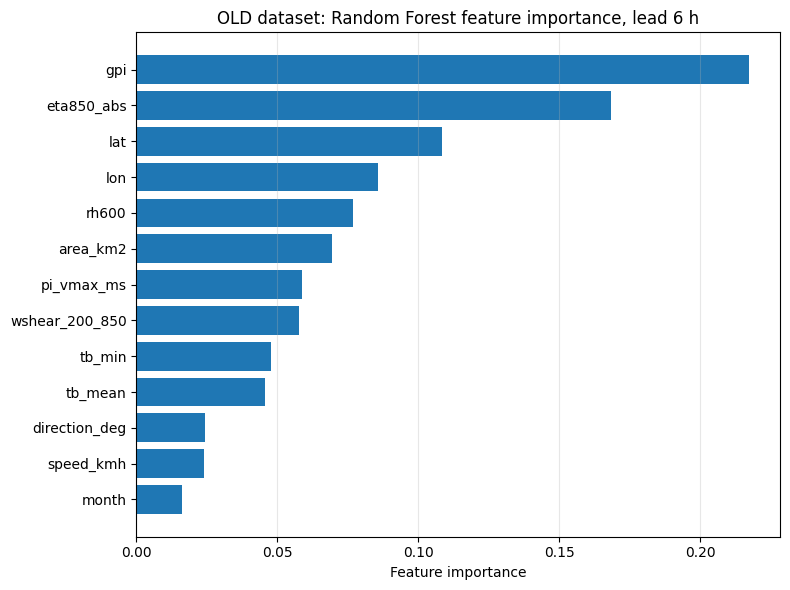

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Random_Forest_6h.png
Feature importance: AdaBoost, lead 6h


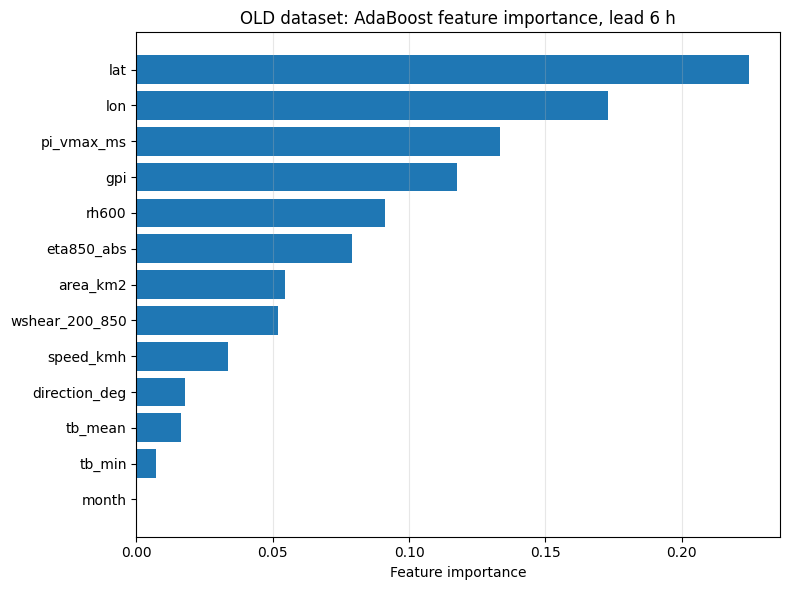

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_AdaBoost_6h.png
Feature importance: Decision Tree, lead 6h


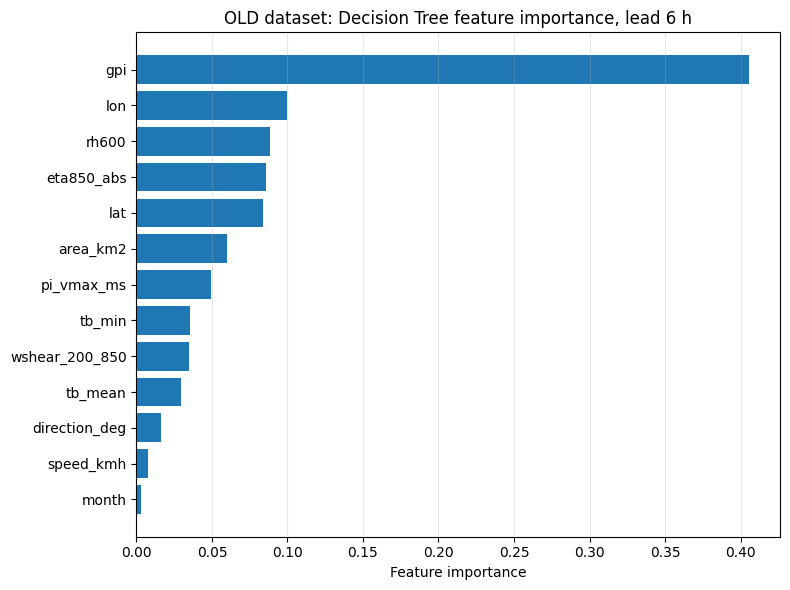

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Decision_Tree_6h.png
Feature importance: Random Forest, lead 12h


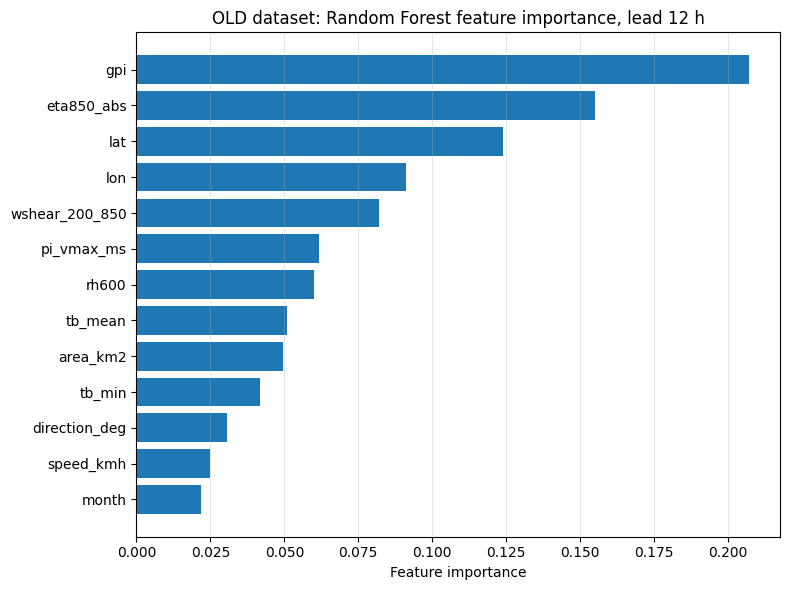

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Random_Forest_12h.png
Feature importance: AdaBoost, lead 12h


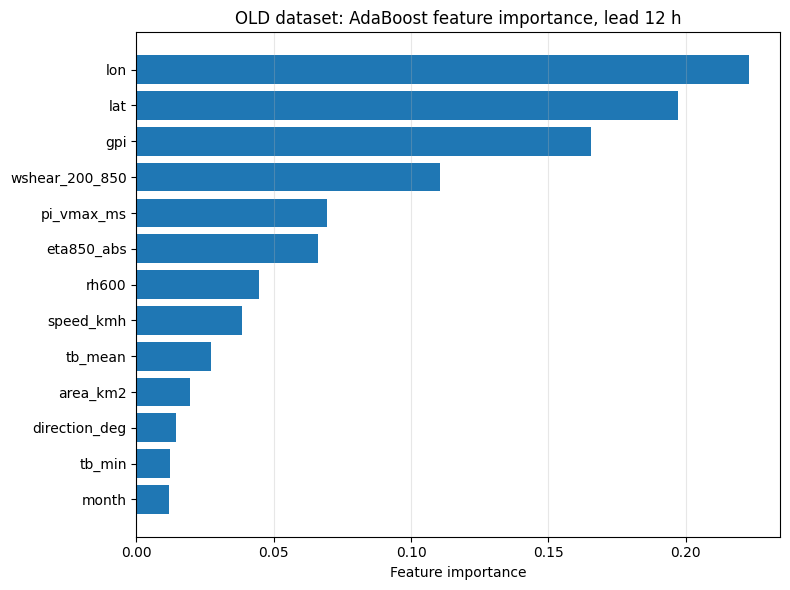

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_AdaBoost_12h.png
Feature importance: Decision Tree, lead 12h


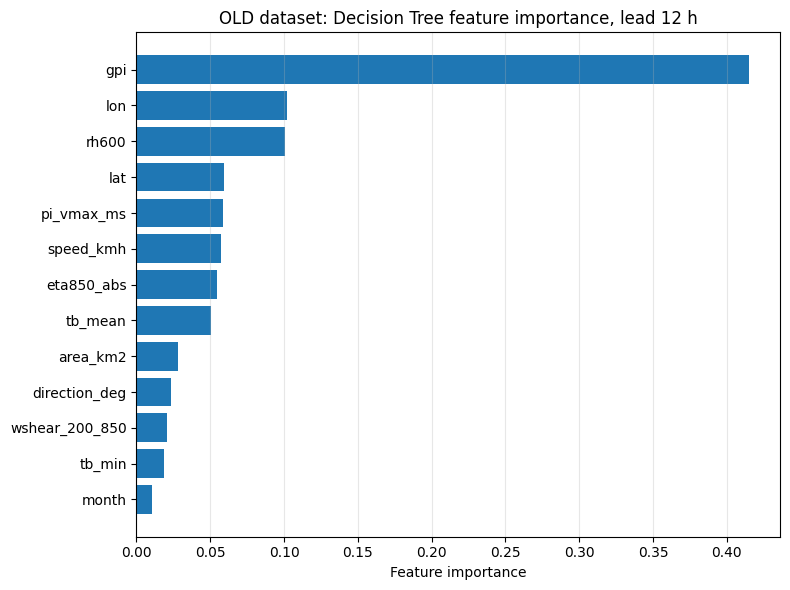

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Decision_Tree_12h.png
Feature importance: Random Forest, lead 24h


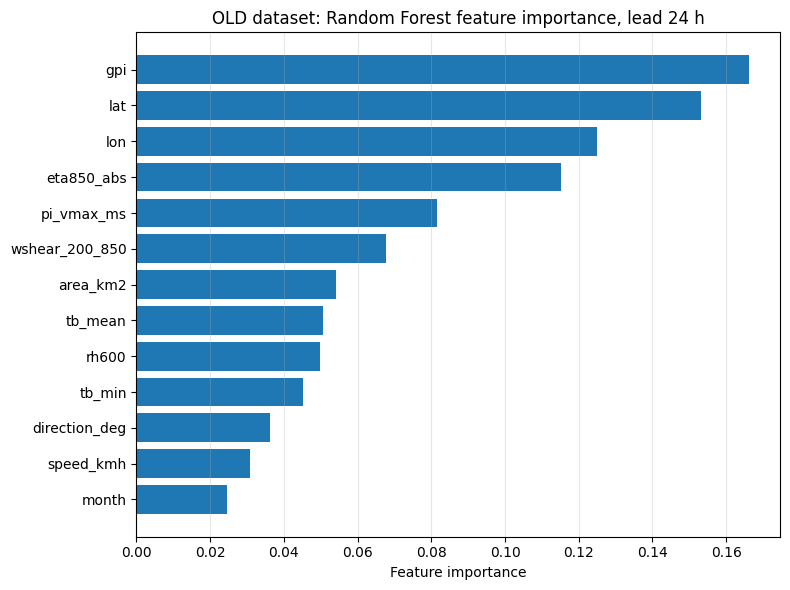

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Random_Forest_24h.png
Feature importance: AdaBoost, lead 24h


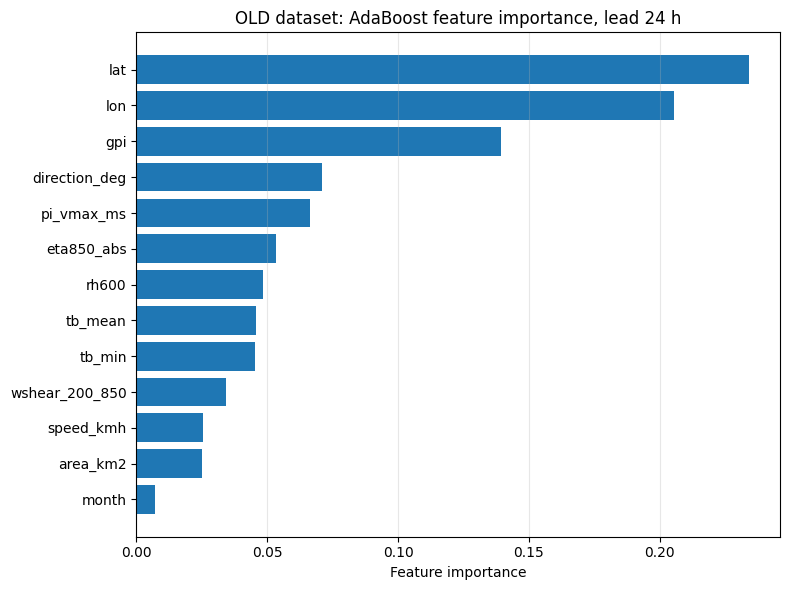

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_AdaBoost_24h.png
Feature importance: Decision Tree, lead 24h


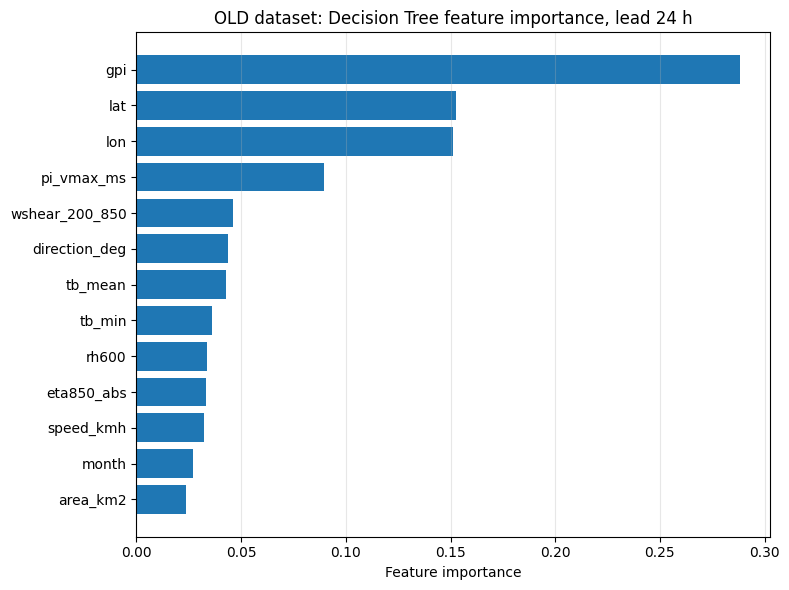

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Decision_Tree_24h.png
Feature importance: Random Forest, lead 48h


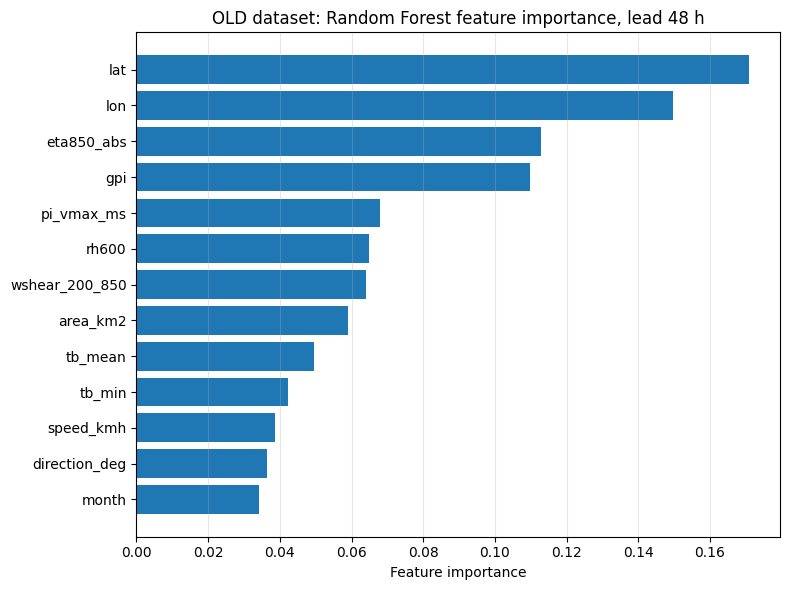

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Random_Forest_48h.png
Feature importance: AdaBoost, lead 48h


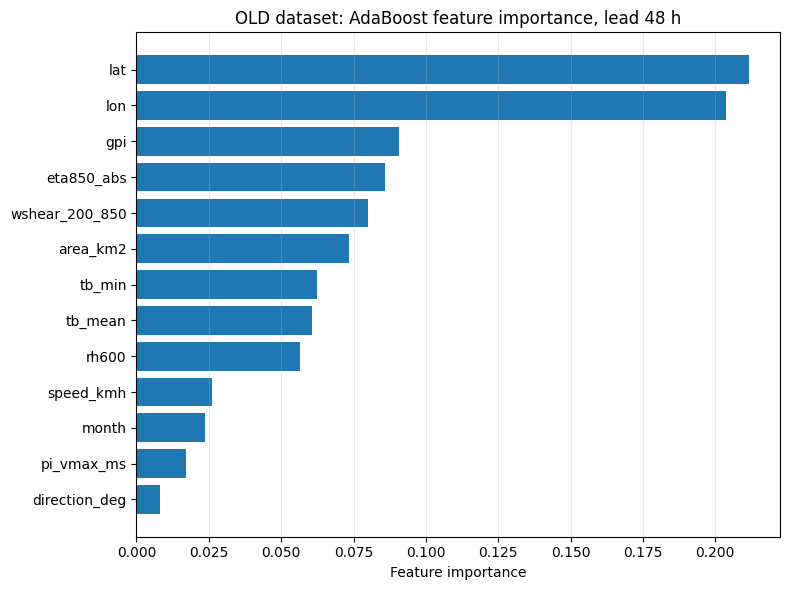

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_AdaBoost_48h.png
Feature importance: Decision Tree, lead 48h


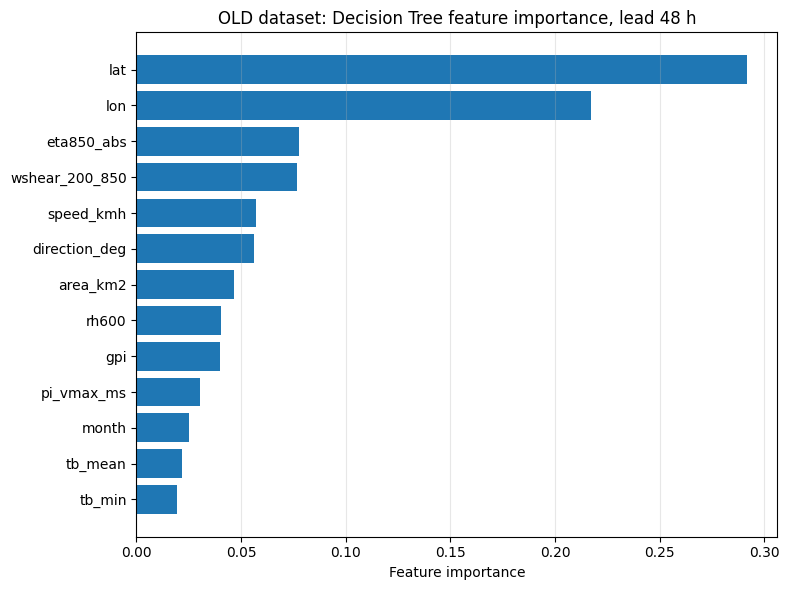

Saved: C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\feature_importance_old\feature_importance_old_Decision_Tree_48h.png


,lead_h,model,feature,importance
14,6,AdaBoost,lat,0.224876
13,6,AdaBoost,lon,0.172907
24,6,AdaBoost,pi_vmax_ms,0.133227
25,6,AdaBoost,gpi,0.117671
22,6,AdaBoost,rh600,0.091303
...,...,...,...,...
121,48,Random Forest,tb_mean,0.049514
122,48,Random Forest,tb_min,0.042139
123,48,Random Forest,speed_kmh,0.038603
124,48,Random Forest,direction_deg,0.036527


In [24]:
# ============================================================
# FEATURE IMPORTANCE — OLD TREE MODELS
# Random Forest / AdaBoost / Decision Tree
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

tree_models = {
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=600,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]),

    "AdaBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", AdaBoostClassifier(
            n_estimators=600,
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        ))
    ]),
}

fi_rows = []

for lead in LEADS:
    df = datasets[lead].copy()

    X = df[FEATURE_COLS].copy()
    y = df["y"].astype(int).values

    for model_name, model in tree_models.items():
        print(f"Feature importance: {model_name}, lead {lead}h")

        model.fit(X, y)
        clf = model.named_steps["clf"]

        if not hasattr(clf, "feature_importances_"):
            print(f"[SKIP] {model_name} has no feature_importances_")
            continue

        imp = pd.DataFrame({
            "lead_h": lead,
            "model": model_name,
            "feature": FEATURE_COLS,
            "importance": clf.feature_importances_,
        })

        fi_rows.append(imp)

        imp_plot = imp.sort_values("importance", ascending=True)

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.barh(imp_plot["feature"], imp_plot["importance"])
        ax.set_xlabel("Feature importance")
        ax.set_title(f"OLD dataset: {model_name} feature importance, lead {lead} h")
        ax.grid(True, axis="x", alpha=0.3)

        plt.tight_layout()

        safe_model = model_name.replace(" ", "_").replace("/", "_")
        out_png = FI_DIR / f"feature_importance_old_{safe_model}_{lead}h.png"

        plt.savefig(out_png, dpi=220, bbox_inches="tight")
        plt.show()

        print("Saved:", out_png)

if fi_rows:
    fi_all = pd.concat(fi_rows, ignore_index=True)
    fi_all.to_csv(FI_DIR / "feature_importance_tree_models_old.csv", index=False)
    display(fi_all.sort_values(["lead_h", "model", "importance"], ascending=[True, True, False]))

2009-2024

In [25]:
# ============================================================
# OLD DATASET — FILTER EXISTING ML OUTPUTS TO 2009–2024
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# ============================================================
# PATHS
# ============================================================

OLD_OUT_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final"
)

OLD_CASE_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\exactlead_box2deg_case_tables_old_2009_2025_JJASO"
)

PLOT_DIR = OLD_OUT_DIR / "plots_old_filtered_2009_2024"
CM_DIR = OLD_OUT_DIR / "confusion_matrices_old_filtered_2009_2024"
FI_DIR = OLD_OUT_DIR / "feature_importance_old_filtered_2009_2024"

PLOT_DIR.mkdir(parents=True, exist_ok=True)
CM_DIR.mkdir(parents=True, exist_ok=True)
FI_DIR.mkdir(parents=True, exist_ok=True)

LEADS = [6, 12, 24, 48]

FEATURE_COLS = [
    "lon", "lat", "month",
    "area_km2", "tb_mean", "tb_min",
    "speed_kmh", "direction_deg",
    "eta850_abs", "rh600", "wshear_200_850",
    "pi_vmax_ms", "gpi"
]

# ============================================================
# LOAD OLD OOF PREDICTIONS
# ============================================================

OOF_CANDIDATES = [
    OLD_OUT_DIR / "oof_predictions_all_models.csv",
    OLD_OUT_DIR / "oof_predictions_allmodels_old.csv",
    OLD_OUT_DIR / "oof_predictions_allmodels.csv",
]

oof_fp = None

for fp in OOF_CANDIDATES:
    if fp.exists():
        oof_fp = fp
        break

if oof_fp is None:
    raise FileNotFoundError(
        "No OLD OOF prediction file found. Checked:\n"
        + "\n".join(str(fp) for fp in OOF_CANDIDATES)
    )

print("Loading OLD OOF predictions:")
print(oof_fp)

oof_old = pd.read_csv(oof_fp)

oof_old["time"] = (
    pd.to_datetime(oof_old["time"], errors="coerce", utc=True)
    .dt.tz_convert(None)
)

print("\nOriginal OLD OOF:")
print("Rows:", len(oof_old))
print("Time range:", oof_old["time"].min(), "to", oof_old["time"].max())
print("Years:", oof_old["time"].dt.year.min(), "-", oof_old["time"].dt.year.max())
print("Models:", sorted(oof_old["model"].dropna().unique()))

# ============================================================
# FILTER TO 2009–2024
# ============================================================

oof_old_0924 = oof_old[
    oof_old["time"].dt.year.between(2009, 2024)
].copy()

print("\nFiltered OLD OOF 2009–2024:")
print("Rows:", len(oof_old_0924))
print("Time range:", oof_old_0924["time"].min(), "to", oof_old_0924["time"].max())
print("Years:", oof_old_0924["time"].dt.year.min(), "-", oof_old_0924["time"].dt.year.max())
print("Models:", sorted(oof_old_0924["model"].dropna().unique()))

Loading OLD OOF predictions:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\oof_predictions_all_models.csv

Original OLD OOF:
Rows: 39474
Time range: 2009-06-01 00:00:00 to 2025-10-30 06:00:00
Years: 2009 - 2025
Models: ['AdaBoost', 'Decision Tree', 'KNN', 'Logistic Regression', 'MLP', 'Naive Bayes', 'QDA', 'Random Forest', 'SVM']

Filtered OLD OOF 2009–2024:
Rows: 37206
Time range: 2009-06-01 00:00:00 to 2024-10-30 12:00:00
Years: 2009 - 2024
Models: ['AdaBoost', 'Decision Tree', 'KNN', 'Logistic Regression', 'MLP', 'Naive Bayes', 'QDA', 'Random Forest', 'SVM']


In [26]:
# ============================================================
# HELPERS FOR FILTERED OLD OOF METRICS
# ============================================================

def get_y_pred_from_oof(sub):
    if "y_pred" in sub.columns:
        return sub["y_pred"].astype(int).values

    if "y_pred_default" in sub.columns:
        return sub["y_pred_default"].astype(int).values

    if "y_score" in sub.columns:
        return (sub["y_score"].astype(float).values >= 0.5).astype(int)

    if "y_prob" in sub.columns:
        return (sub["y_prob"].astype(float).values >= 0.5).astype(int)

    raise ValueError(
        "No prediction column found. Need one of: "
        "y_pred, y_pred_default, y_score, y_prob."
    )


def get_y_score_from_oof(sub):
    if "y_score" in sub.columns:
        return sub["y_score"].astype(float).values

    if "y_prob" in sub.columns:
        return sub["y_prob"].astype(float).values

    return None


def compute_metrics_from_oof(sub):
    y_true = sub["y_true"].astype(int).values
    y_pred = get_y_pred_from_oof(sub)
    y_score = get_y_score_from_oof(sub)

    out = {
        "samples": len(sub),
        "positive": int(y_true.sum()),
        "negative": int((y_true == 0).sum()),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    if y_score is not None and len(np.unique(y_true)) > 1:
        out["roc_auc"] = roc_auc_score(y_true, y_score)
        out["pr_auc"] = average_precision_score(y_true, y_score)
    else:
        out["roc_auc"] = np.nan
        out["pr_auc"] = np.nan

    return out


# ============================================================
# BUILD FILTERED SUMMARY TABLE
# ============================================================

summary_rows = []

for (lead_h, model), sub in oof_old_0924.groupby(["lead_h", "model"]):
    metrics = compute_metrics_from_oof(sub)

    summary_rows.append({
        "dataset": "old",
        "period": "2009-2024",
        "lead_h": int(lead_h),
        "model": model,
        **metrics
    })

summary_old_0924 = pd.DataFrame(summary_rows)

summary_old_0924 = (
    summary_old_0924
    .sort_values(["lead_h", "f1"], ascending=[True, False])
    .reset_index(drop=True)
)

out_summary = OLD_OUT_DIR / "cv_summary_results_old_filtered_2009_2024_from_oof.csv"
summary_old_0924.to_csv(out_summary, index=False)

print("Saved filtered summary:")
print(out_summary)

display(summary_old_0924)

# Ranked table
ranked_table_old_0924 = summary_old_0924[
    ["lead_h", "model", "precision", "recall", "f1", "roc_auc", "pr_auc"]
].copy()

ranked_table_old_0924.to_csv(
    OLD_OUT_DIR / "model_performance_ranked_by_lead_old_filtered_2009_2024.csv",
    index=False
)

# Best model by lead
best_by_lead_old_0924 = (
    ranked_table_old_0924
    .sort_values(["lead_h", "f1"], ascending=[True, False])
    .groupby("lead_h", as_index=False)
    .first()
)

best_by_lead_old_0924.to_csv(
    OLD_OUT_DIR / "best_model_by_lead_old_filtered_2009_2024.csv",
    index=False
)

print("\nBest model by lead:")
display(best_by_lead_old_0924)

Saved filtered summary:
C:\Users\_s2218026\Documents\lab\mcs_output\ml_old_box2deg_2009_2025_final\cv_summary_results_old_filtered_2009_2024_from_oof.csv


,dataset,period,lead_h,model,samples,positive,negative,accuracy,precision,recall,f1,roc_auc,pr_auc
0,old,2009-2024,6,MLP,1254,223,1031,0.858852,0.617347,0.542601,0.577566,0.865253,0.601902
1,old,2009-2024,6,Random Forest,1254,223,1031,0.874003,0.715232,0.484305,0.577540,0.907369,0.687721
2,old,2009-2024,6,Naive Bayes,1254,223,1031,0.862041,0.635870,0.524664,0.574939,0.861987,0.556046
3,old,2009-2024,6,Logistic Regression,1254,223,1031,0.789474,0.447837,0.789238,0.571429,0.862252,0.558461
4,old,2009-2024,6,AdaBoost,1254,223,1031,0.862839,0.649123,0.497758,0.563452,0.890563,0.622740
5,old,2009-2024,6,SVM,1254,223,1031,0.867624,0.693878,0.457399,0.551351,0.888001,0.660663
6,old,2009-2024,6,QDA,1254,223,1031,0.859649,0.647799,0.461883,0.539267,0.868235,0.563769
7,old,2009-2024,6,Decision Tree,1254,223,1031,0.829346,0.521127,0.497758,0.509174,0.699412,0.348709
8,old,2009-2024,6,KNN,1254,223,1031,0.853270,0.638298,0.403587,0.494505,0.800766,0.503065
9,old,2009-2024,12,Naive Bayes,1175,207,968,0.861277,0.637500,0.492754,0.555858,0.843709,0.544219



Best model by lead:


,lead_h,model,precision,recall,f1,roc_auc,pr_auc
0,6,MLP,0.617347,0.542601,0.577566,0.865253,0.601902
1,12,Naive Bayes,0.637500,0.492754,0.555858,0.843709,0.544219
2,24,AdaBoost,0.537879,0.405714,0.462541,0.833826,0.512704
3,48,MLP,0.451613,0.333333,0.383562,0.762408,0.363275


In [27]:
from pathlib import Path
import pandas as pd

CASE_2025_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\exactlead_box2deg_case_tables_old_2009_2025_JJASO"
)

CASE_2024_DIR = Path(
    r"C:\Users\_s2218026\Documents\lab\mcs_output\exactlead_box2deg_case_tables_old_2009_2024_JJASO"
)

LEADS = [6, 12, 24, 48]

for L in LEADS:
    fp25 = CASE_2025_DIR / f"box2deg_case_table_old_{L}h.csv"
    fp24 = CASE_2024_DIR / f"box2deg_case_table_old_{L}h.csv"

    df25 = pd.read_csv(fp25)
    df24 = pd.read_csv(fp24)

    df25["time"] = pd.to_datetime(df25["time"], errors="coerce", utc=True).dt.tz_convert(None)
    df24["time"] = pd.to_datetime(df24["time"], errors="coerce", utc=True).dt.tz_convert(None)

    print("\n" + "=" * 60)
    print(f"Lead {L}h")

    print("2009–2025 rows:", len(df25))
    print("2009–2024 rows:", len(df24))

    print("2009–2025 positives:", int(df25["y"].sum()))
    print("2009–2024 positives:", int(df24["y"].sum()))

    print("2009–2025 negatives:", int((df25["y"] == 0).sum()))
    print("2009–2024 negatives:", int((df24["y"] == 0).sum()))

    print("2025 rows inside 2009–2025 case table:", int((df25["time"].dt.year == 2025).sum()))
    print("2025 positives inside 2009–2025 case table:", int(df25.loc[df25["time"].dt.year == 2025, "y"].sum()))

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\_s2218026\\Documents\\lab\\mcs_output\\exactlead_box2deg_case_tables_old_2009_2024_JJASO\\box2deg_case_table_old_6h.csv'

In [ ]:
# ============================================================
# OLD FILTERED 2009–2024 — BAR PLOTS
# ============================================================

MODEL_ORDER_CANDIDATES = [
    "Logistic Regression", "Logistic",
    "Naive Bayes", "NaiveBayes",
    "KNN",
    "SVM",
    "Decision Tree", "DecisionTree",
    "MLP",
    "QDA",
    "Random Forest", "RandomForest",
    "AdaBoost",
]

available_models = summary_old_0924["model"].dropna().unique().tolist()
MODEL_ORDER = [m for m in MODEL_ORDER_CANDIDATES if m in available_models]

# Add any remaining models not covered above
MODEL_ORDER += [m for m in available_models if m not in MODEL_ORDER]

summary_plot = summary_old_0924.copy()
summary_plot["model"] = pd.Categorical(summary_plot["model"], categories=MODEL_ORDER, ordered=True)
summary_plot = summary_plot.sort_values(["model", "lead_h"]).copy()

lead_order = [6, 12, 24, 48]


def make_bar_metric_old_0924(metric, ylabel, title, outname):
    piv = summary_plot.pivot(index="model", columns="lead_h", values=metric)
    piv = piv.reindex(MODEL_ORDER)

    existing_leads = [L for L in lead_order if L in piv.columns]
    piv = piv[existing_leads]

    x = np.arange(len(piv.index))
    width = 0.18

    fig, ax = plt.subplots(figsize=(12, 5.5))

    for i, lead in enumerate(existing_leads):
        ax.bar(
            x + (i - (len(existing_leads)-1)/2) * width,
            piv[lead],
            width=width,
            label=f"{lead} h"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(piv.index, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Model")
    ax.set_title(title)
    ax.legend(title="Lead")
    ax.grid(True, axis="y", alpha=0.3)

    plt.tight_layout()

    out_png = PLOT_DIR / outname
    plt.savefig(out_png, dpi=220, bbox_inches="tight")
    plt.show()

    print("Saved:", out_png)


make_bar_metric_old_0924(
    metric="f1",
    ylabel="F1 score",
    title="OLD dataset (filtered to 2009–2024): F1 score by model and lead time",
    outname="bar_f1_by_model_lead_old_filtered_2009_2024.png"
)

make_bar_metric_old_0924(
    metric="precision",
    ylabel="Precision",
    title="OLD dataset (filtered to 2009–2024): Precision by model and lead time",
    outname="bar_precision_by_model_lead_old_filtered_2009_2024.png"
)

make_bar_metric_old_0924(
    metric="recall",
    ylabel="Recall",
    title="OLD dataset (filtered to 2009–2024): Recall by model and lead time",
    outname="bar_recall_by_model_lead_old_filtered_2009_2024.png"
)